# ITD224 Applied Data Science Project

| | |
|---|---|
| **Team Project Name** | Singapore Real Estate Intelligence Platform |
| **Name** | Tan Tien Hock |
| **Student ID** | 6968437D |
| **Team Individual Assignment Topic** | Condominium Rental Rate Prediction |
| **Framework** | CRISP-DM |
| **Dataset** | `Condo_Rental.csv` (URA-based Executive Condominium rental transactions, 10,000 records) |

**Business Objective:** Predict monthly condominium rental prices and identify the key factors affecting rental values — enabling agencies
to advise landlords and tenants with competitive, model-backed confidence, and to benchmark rentals against **location convenience**
(proximity to MRT, supermarkets and schools) sourced from Singapore's **OneMap API**.

This notebook covers the full CRISP-DM cycle for this workstream: **Business Understanding → Data Understanding → Data Preparation (Integrate / Clean/ Format/ Verification/ Construct/ Interactive Data Exploration (ipywidgets)/ GPS Map Visualisation/ Amenity-Proximity Impact Analysis/ Data Quality Summary (Before vs. After)/ Export Cleaned & Enriched Dataset) → Modelling & Evaluation → Recommendations → AI Ethics**.



## Table of Contents

1. [Business Understanding (Recap)](#1)
2. [Data Understanding](#2)
    - [2.1 Data Collection Source](#2.1)
    - [2.2 Data Quality Findings](#2.2)
3. [Data Selection](#3)
4. [Data Preparation](#4)
    - [4.1 Integrate Data - GPS Enrichment via OneMap API](#4.1)
    - [4.2 Integrate Data - Building Age via OneMap SLA Address + Jigtech Search](#4.2)
    - [4.3 Integrate Data - Nearby Amenities via OneMap Search API & Open Rail Data](#4.3)
    - [4.4 Data Clean](#4.4)
    - [4.5 Data Verification](#4.5)
    - [4.6 Format Data (Type Casting & Feature Selection)](#4.6)
    - [4.7 Construct Data (Feature Engineering)](#4.7)
    - [4.8 Interactive Data Exploration (ipywidgets)](#4.8)
    - [4.9 GPS Map Visualisation](#4.9)
    - [4.10 Amenity-Proximity Impact Analysis](#4.10)
    - [4.11 Data Quality Summary (Before vs. After)](#4.11)
    - [4.12 Export Cleaned & Enriched Dataset](#4.12)
    - [4.13 Pre-selection Features](#4.13)
5. [Modelling & Evaluation (Key Task 4)](#5)
    - [5.0a Cross-Validated Model Comparison (Reliability Check)](#5.0a)
    - [5.1 Hyperparameter Tuning](#5.1)
    - [5.2 Feature Importance -- What Actually Drives Rent?](#5.2)
6. [Evaluation Against Business Objectives](#6)
7. [Recommendations -- Who Benefits & How](#7)
8. [AI Ethics Considerations](#8)
9. [Limitations & Future Work](#9)
- [References](#references)

---


<a id="1"></a>
## 1. Business Understanding (Recap)

| Item | Description |
|---|---|
| **Business Goal** | Help a Singapore real estate agency make better property pricing, rental and customer-targeting decisions using ML. |
| **Alan's Objective** | Predict monthly condominium rental prices and identify the key pricing factors, enabling landlords, tenants and agencies to benchmark competitively with model confidence. |
| **Data Mining Goal** | Build and compare regression models (Linear Regression, Random Forest, XGBoost) to predict `Monthly Rent ($)`, using both **property attributes** (bedrooms, floor size, lease age, district) and **location-convenience features** engineered from the OneMap API (distance to nearest MRT / supermarket / school). |
| **Success Criteria** | Model achieves a materially lower MAE/RMSE than a naive district-average baseline, with an interpretable feature-importance ranking the agency can act on. |

<a id="2"></a>
## 2. Data Understanding

<a id="2.1"></a>
### 2.1 Data Collection Source

The dataset originates from **URA (Urban Redevelopment Authority) private residential property rent statistics**, filtered to **Executive Condominium** transactions across Singapore postal districts 18–28 (spanning North, North-East, and East regions). It was supplied as `Condo_Rental.csv`.

We enrich this base dataset with **geospatial data from Singapore's OneMap API** (a public government geospatial platform: https://www.onemap.gov.sg/apidocs/) to add:

1. **GPS coordinates** (Latitude / Longitude) for each rental transaction
2. **Distance to nearest MRT station, supermarket, and school** — key drivers of rental value not present in the raw URA extract

In [ ]:
# ==============================================================
# STEP    : Environment Setup
# PURPOSE : Import every library used in this notebook and set all global /
#           plotting defaults so all later charts share a consistent look.
# INPUT   : None (standard library + third-party packages already installed)
# OUTPUT  : None (side effect: configures pandas/matplotlib/seaborn defaults)
# ==============================================================
# -- Core imports --
import pandas as pd
import numpy as np
import re
import time
import json
import warnings
from datetime import datetime
import requests

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries loaded.")

Libraries loaded.


In [ ]:
# ==============================================================
# STEP    : Data Understanding -- Load Raw Data
# PURPOSE : Read the raw URA-sourced CSV into a DataFrame and confirm its size.
# INPUT   : Condo_Rental.csv (must be uploaded to the Colab/working directory)
# OUTPUT  : df_raw -- the untouched raw DataFrame used throughout Section 2
# ==============================================================
# -- Load raw dataset --
RAW_PATH = "Condo_Rental.csv"  # place file in the same Colab/working directory

df_raw = pd.read_csv(RAW_PATH)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 10,000 rows x 9 columns


,Project Name,Street Name,Postal District,Property Type,No of Bedroom,Monthly Rent ($),Floor Area (SQM),Floor Area (SQFT),Lease Commencement Date
0,THE RAINFOREST,CHOA CHU KANG AVENUE 3,23,Executive Condominium,3.00,"5,000",130 to 140,"1,400 to 1,500",Jun-26
1,SIMEI GREEN CONDOMINIUM,SIMEI STREET 4,18,Executive Condominium,3.00,"4,100",110 to 120,"1,200 to 1,300",Jun-26
2,PINEVALE,TAMPINES STREET 73,18,Executive Condominium,3.00,"4,600",120 to 130,"1,200 to 1,300",Jun-26
3,ECOPOLITAN,PUNGGOL WALK,19,Executive Condominium,3.00,"4,000",100 to 110,"1,000 to 1,100",Jun-26
4,NUOVO,ANG MO KIO AVENUE 9,20,Executive Condominium,3.00,"3,850",100 to 110,"1,100 to 1,200",Jun-26


In [ ]:
# ==============================================================
# STEP    : Data Understanding -- Structural Profile
# PURPOSE : Inspect column names, dtypes, and non-null counts to understand the
#           raw schema before any cleaning is applied.
# INPUT   : df_raw
# OUTPUT  : Printed schema summary (no new variables)
# ==============================================================
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Project Name             10000 non-null  object 
 1   Street Name              10000 non-null  object 
 2   Postal District          10000 non-null  int64  
 3   Property Type            10000 non-null  object 
 4   No of Bedroom            9997 non-null   float64
 5   Monthly Rent ($)         10000 non-null  object 
 6   Floor Area (SQM)         10000 non-null  object 
 7   Floor Area (SQFT)        10000 non-null  object 
 8   Lease Commencement Date  10000 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 703.3+ KB


In [ ]:
# ==============================================================
# STEP    : Data Understanding -- Missing Value Audit
# PURPOSE : Quantify exactly which fields have missing values and how many, so
#           the cleaning plan in Section 4 targets the right columns.
# INPUT   : df_raw
# OUTPUT  : missing -- a summary table of missing counts/percentages per column
# ==============================================================
missing = df_raw.isna().sum().to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df_raw) * 100).round(2)
missing[missing['missing_count'] > 0]

,missing_count,missing_pct
No of Bedroom,3,0.03


**Observation:** Only `No of Bedroom` has missing values (3 rows, 0.03%). All other fields are fully populated but stored as **strings with formatting** (thousand separators, ranges, abbreviated dates) that must be cleaned before analysis.

In [ ]:
# ==============================================================
# STEP    : Data Understanding -- Categorical Field Profiling
# PURPOSE : Print value counts for every categorical/discrete field to check
#           for unexpected categories, class imbalance, or constant columns.
# INPUT   : df_raw
# OUTPUT  : Printed value_counts() per column (no new variables)
# ==============================================================
for col in ['Postal District', 'Property Type', 'No of Bedroom', 'Lease Commencement Date']:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False).sort_index())
    print()

--- Postal District ---
Postal District
18    2286
19    2282
20     280
22    1198
23    1120
24       1
25    1505
27    1096
28     232
Name: count, dtype: int64

--- Property Type ---
Property Type
Executive Condominium    10000
Name: count, dtype: int64

--- No of Bedroom ---
No of Bedroom
1.00      65
2.00     968
3.00    7905
4.00     987
5.00      72
NaN        3
Name: count, dtype: int64

--- Lease Commencement Date ---
Lease Commencement Date
Apr-22    139
Apr-23    142
Apr-24    160
Apr-25    194
Apr-26    216
Aug-21     98
Aug-22    157
Aug-23    188
Aug-24    192
Aug-25    229
Dec-21    168
Dec-22    173
Dec-23    149
Dec-24    213
Dec-25    205
Feb-22    110
Feb-23    140
Feb-24    132
Feb-25    147
Feb-26    156
Jan-22    195
Jan-23    161
Jan-24    163
Jan-25    195
Jan-26    210
Jul-22    166
Jul-23    179
Jul-24    194
Jul-25    251
Jun-22    153
Jun-23    173
Jun-24    201
Jun-25    226
Jun-26    211
Mar-22    160
Mar-23    161
Mar-24    197
Mar-25    180
Mar-26    2

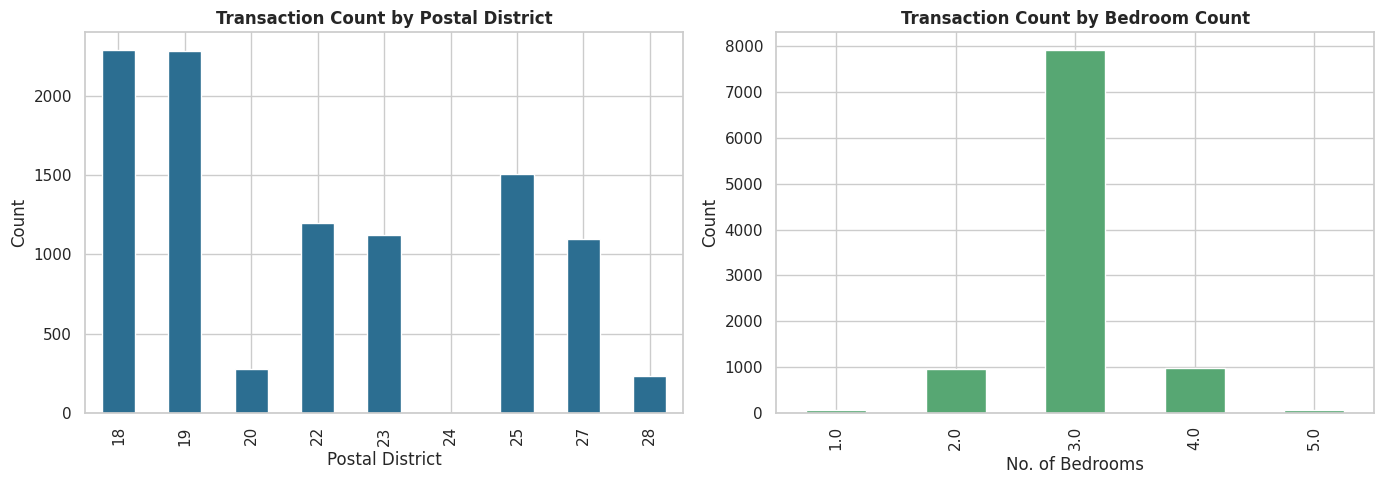

In [ ]:
# ==============================================================
# STEP    : Data Understanding -- Visual Exploration (1/2)
# PURPOSE : Bar-chart the transaction count by Postal District and by Bedroom
#           Count to visually confirm the class-imbalance patterns seen above.
# INPUT   : df_raw
# OUTPUT  : Two bar charts (displayed inline, not stored in a variable)
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw['Postal District'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#2c6e91')
axes[0].set_title('Transaction Count by Postal District')
axes[0].set_xlabel('Postal District'); axes[0].set_ylabel('Count')

df_raw['No of Bedroom'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#57a773')
axes[1].set_title('Transaction Count by Bedroom Count')
axes[1].set_xlabel('No. of Bedrooms'); axes[1].set_ylabel('Count')

plt.tight_layout(); plt.show()

**Interpretation:** Transactions concentrate heavily in Districts 18-20 (Tampines/Pasir Ris, Sengkang/Punggol, Bishan/AMK), which together account for over half of all records -- the model will therefore have far more signal to learn from in these districts than in the thinner Districts 24/25/28 (Lim Chu Kang/Woodgrove/Seletar), a class-imbalance risk worth flagging for the fairness discussion later. Bedroom count is dominated by 3-bedroom units (79% of the dataset), with a strongly right-skewed tail toward 1- and 5-bedroom units, so 4/5-bedroom rent predictions will have much less training data to draw on and should be treated with lower confidence.

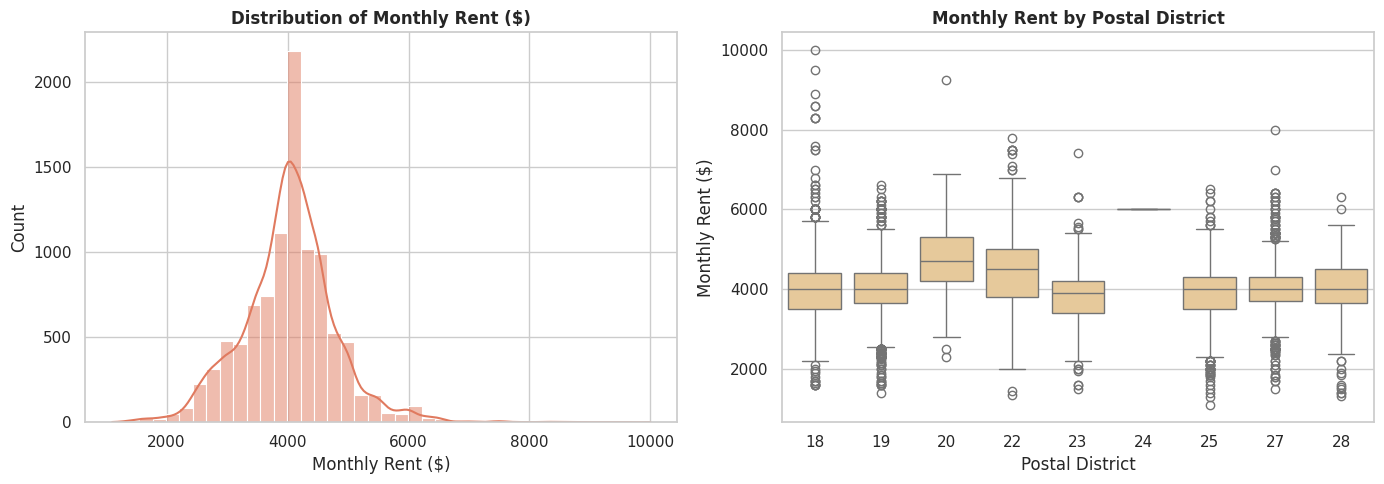

count   10,000.00
mean     4,024.53
std        771.39
min      1,100.00
25%      3,600.00
50%      4,000.00
75%      4,500.00
max     10,000.00
Name: Monthly Rent ($), dtype: float64


In [ ]:
# ==============================================================
# STEP    : Data Understanding -- Visual Exploration (2/2)
# PURPOSE : Preview the rent distribution (histogram + boxplot by district)
#           using a quick comma-stripped numeric series, ahead of the full
#           cleaning pipeline in Section 4.
# INPUT   : df_raw
# OUTPUT  : rent_preview -- a throwaway numeric Series, used only for these plots
# ==============================================================
rent_preview = df_raw['Monthly Rent ($)'].str.replace(',', '', regex=False).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(rent_preview, bins=40, kde=True, ax=axes[0], color='#e07a5f')
axes[0].set_title('Distribution of Monthly Rent ($)')
axes[0].set_xlabel('Monthly Rent ($)')

sns.boxplot(x=df_raw['Postal District'], y=rent_preview, ax=axes[1], color='#f2cc8f')
axes[1].set_title('Monthly Rent by Postal District')
axes[1].set_xlabel('Postal District'); axes[1].set_ylabel('Monthly Rent ($)')

plt.tight_layout(); plt.show()
print(rent_preview.describe())

**Interpretation:** Monthly rent is right-skewed with a long tail toward higher-value units, and the median (~$4,000 based on the describe() output above) sits below the mean, confirming a small number of premium/large units pull the average upward -- this motivates treating rent outliers as a flag rather than deleting them, since they represent genuine premium-market transactions, not data errors. The boxplot shows District 18 and District 20 have both the highest median rents and the widest interquartile spread, suggesting these districts have a broader range of unit tiers (older vs. newer developments) that later feature engineering (`Building_Age_Years`, `Price_per_SQFT`) should help the model disentangle.

<a id="2.2"></a>
### 2.2 Data Quality Findings

| # | Issue | Field(s) Affected | Resolution Plan |
|---|---|---|---|
| 1 | Numbers stored as text with thousand-separator commas | `Monthly Rent ($)` | Strip commas, cast to float |
| 2 | Values stored as ranges (URA privacy-preserving banding), not exact figures | `Floor Area (SQM)`, `Floor Area (SQFT)` | Convert to numeric midpoint of each 10-unit band |
| 3 | Dates stored as abbreviated 'Mon-YY' strings | `Lease Commencement Date` | Parse to datetime; derive `Lease_Commencement_Year` |
| 4 | 3 missing values (0.03%) | `No of Bedroom` | Impute using the median bedroom count of properties with the same floor-area band |
| 5 | Constant column (only 1 unique value: Executive Condominium) | `Property Type` | Retain for documentation, exclude from modelling features (zero variance = zero predictive value) |
| 6 | No location / accessibility information | entire dataset | Integrate GPS coordinates and location-convenience features via OneMap |
| 7 | Potential outliers (very high/low rent for given size) | `Monthly Rent ($)` | Flag via IQR method; verified rather than blindly dropped |
| 7b | A small number of `Jigtech_Search_TOP_Year` values are later than `REFERENCE_YEAR`, which produced a negative `Building_Age_Years` in the raw calculation | `Building_Age_Years` | Clip at a minimum of 0 (§4.2) |
| 8 | `Lease Commencement Date` is the **rental tenancy's** start date, not the building's construction/completion date -- an earlier version of this notebook incorrectly derived a `Property_Age_Years` field from it and used that as a proxy for building age | `Lease Commencement Date` | Corrected in §4.3c: real building age is now sourced from a live OneMap (address) + jigtech_search (web search) auto-lookup of each project's TOP (Temporary Occupation Permit) year, stored as `Building_Age_Years` |

<a id="3"></a>
## 3. Data Selection

### Rationale for inclusion / exclusion of fields

| Field | Decision | Rationale |
|---|---|---|
| `Project Name`, `Street Name` | Keep | Required as the gecoding query input for OneMap GPS enrichment; retained as identifiers, not model features |
| `Postal District` | Keep | Strong locational proxy; used both as a categorical feature and as the geocoding fallback |
| `Property Type` | Keep (documentation only) | Constant value across all 10,000 rows -- dropped from the eventual model feature set, but retained in the cleaned file for transparency |
| `No of Bedroom` | Keep | Direct driver of rent used; No of Bedroom engineered feature |
| `Monthly Rent ($)` | Keep -- target variable | Primary determinant of rent the model predicts |
| `Floor Area (SQM)` / `(SQFT)` | Keep | Basis for `Price_per_SQFT`, a known driver of rental pricing |
| `Lease Commencement Date` | Keep | Basis for `Lease_Commencement_Year` -- reflects when this specific rental transaction's lease begins, a time-trend signal. **Not** a basis for building age (see Data Quality Finding #8 above) |
| (new) `Latitude`/`Longitude`/`Postal_Code` | Add via OneMap | Enables distance-to-amenity feature engineering and map-based data storytelling |
| (new) `Nearest_MRT_Distance_KM`, `Nearest_Supermarket_Distance_KM`, `Nearest_School_Distance_KM` | Add via OneMap | Location convenience is one of the most cited drivers of Singapore rental prices -- not present in the raw URA extract, but it is engineered here because it is likely here to materially improve model signal |
| (new) `Building_Age_Years` | Add via OneMap + jigtech_search auto-search | The genuine building-age signal that `Property_Age_Years` was mistakenly standing in for; a known driver of rental depreciation |

No rows were excluded at this stage -- all 10,000 transactions are within the intended EC (Executive Condominium) scope and region (Districts 18-28). All 10,000 rows are carried through the full pipeline; a row only ends up with an `Unknown` `Building_Age_Years` if the live OneMap + jigtech_search lookup in §4.3c genuinely cannot resolve it (see that section for why, and why rows are never dropped pre-emptively based on a guess about the project name alone).

In [ ]:
# ==============================================================
# STEP    : Data Selection
# PURPOSE : Formalise the field-selection decision made in the markdown above --
#           all 10,000 rows and all columns are retained (no row/column
#           dropped at this stage; exclusions happen later at the model-feature
#           level, e.g. dropping the constant Property Type column).
# INPUT   : df_raw
# OUTPUT  : df -- the working copy that every subsequent Data Preparation step
#           builds on
# ==============================================================
df = df_raw.copy()
print("Rows retained:", len(df))

Rows retained: 10000


<a id="4"></a>
## 4. Data Preparation
<a id="4.1"></a>
### 4.1 Integrate Data - GPS Enrichment via OneMap API

This step adds OneMap SLA address, postal and coordinate fields to the existing cleaned dataframe; it does not reload the raw CSV. After enrichment, the required SLA quality gate lists incomplete records and removes rows missing a postal code, address, latitude or longitude before distance calculation, mapping, export and modelling.


In [ ]:
import re, time
from pathlib import Path
import numpy as np
import pandas as pd
import requests

# Configuration
INPUT_FILE = 'Condo_Rental.csv'
TOKEN_FILE = 'token.txt'
OUTPUT_FILE = 'Condo_OneMap_Jigtech_Search_TOP_Enriched.csv'

# Load Data
try:
    df = pd.read_csv(INPUT_FILE, encoding='utf-8-sig')
except FileNotFoundError:
    raise FileNotFoundError(f"{INPUT_FILE} not found. Please upload it to Colab.")

# Load Token
try:
    with open(TOKEN_FILE, 'r') as f:
        ONEMAP_TOKEN = f.read().strip()
except FileNotFoundError:
    ONEMAP_TOKEN = None
    print("Warning: token.txt not found. Proceeding without authentication.")

def norm(x): return re.sub(r'[^a-z0-9]+','',str(x).casefold())
cols={norm(c):c for c in df.columns}
def col(names,default=None): return next((cols[norm(x)] for x in names if norm(x) in cols),default)

project_col=col(['Project Name','Project','Development'],df.columns[0])
street_col=col(['Street Name','Street','Road Name','Address'])
district_col=col(['Postal District','District','Postal Sector'])

def clean(v): return '' if pd.isna(v) else re.sub(r'\s+',' ',str(v).strip())
def rowkey(r): return (clean(r[project_col]).upper(),clean(r[street_col]).upper() if street_col else '',clean(r[district_col]).upper() if district_col else '')

session=requests.Session()

def one(project,street,district):
    empty={'SLA_Postal':pd.NA,'SLA_Latitude':np.nan,'SLA_Longitude':np.nan,'SLA_Address':pd.NA,'SLA_Building':pd.NA,'SLA_Road_Name':pd.NA,'SLA_Search_Query':pd.NA,'SLA_Status':'not found'}
    queries=[' '.join(x for x in (project,street,district,'Singapore') if x),' '.join(x for x in (street,district,'Singapore') if x),' '.join(x for x in (project,'Singapore') if x)]
    for q in dict.fromkeys(x for x in queries if x):
        try:
            headers = {'Authorization': ONEMAP_TOKEN} if ONEMAP_TOKEN else {}
            r=session.get('https://www.onemap.gov.sg/api/common/elastic/search',params={'searchVal':q,'returnGeom':'Y','getAddrDetails':'Y','pageNum':1},headers=headers,timeout=30)
            r.raise_for_status()
            hits=r.json().get('results',[])
            if hits:
                x=max(hits,key=lambda h:(project in ' '.join(str(h.get(z,'')) for z in ('BUILDING','ADDRESS')).upper())*5+(street in str(h.get('ROAD_NAME','')).upper())*4)
                return {'SLA_Postal':x.get('POSTAL') or pd.NA,'SLA_Latitude':pd.to_numeric(x.get('LATITUDE'),errors='coerce'),'SLA_Longitude':pd.to_numeric(x.get('LONGITUDE'),errors='coerce'),'SLA_Address':x.get('ADDRESS') or pd.NA,'SLA_Building':x.get('BUILDING') or pd.NA,'SLA_Road_Name':x.get('ROAD_NAME') or pd.NA,'SLA_Search_Query':q,'SLA_Status':'matched'}
        except requests.RequestException as e: empty['SLA_Status']=f'request failed: {type(e).__name__}'
    return empty

keys=df.apply(rowkey,axis=1); mapping={}
unique_keys = list(dict.fromkeys(keys))
print(f"Processing {len(unique_keys)} unique locations...")

for i,k in enumerate(unique_keys,1):
    if i % 1 == 0: print(f'OneMap Progress: {i}/{len(unique_keys)}')
    mapping[k]=one(*k)
    time.sleep(.25)

# IDEMPOTENCY FIX: Drop existing SLA columns to avoid duplicate column name errors on re-run
df=df.drop(columns=[c for c in df.columns if c.startswith('SLA_')], errors='ignore')

# Merge Results
df=pd.concat([df,pd.DataFrame([mapping[k] for k in keys],index=df.index)],axis=1)

print('OneMap complete:',df.SLA_Status.value_counts().to_dict())
display(df.head())

Processing 76 unique locations...
OneMap Progress: 1/76
OneMap Progress: 2/76
OneMap Progress: 3/76
OneMap Progress: 4/76
OneMap Progress: 5/76
OneMap Progress: 6/76
OneMap Progress: 7/76
OneMap Progress: 8/76
OneMap Progress: 9/76
OneMap Progress: 10/76
OneMap Progress: 11/76
OneMap Progress: 12/76
OneMap Progress: 13/76
OneMap Progress: 14/76
OneMap Progress: 15/76
OneMap Progress: 16/76
OneMap Progress: 17/76
OneMap Progress: 18/76
OneMap Progress: 19/76
OneMap Progress: 20/76
OneMap Progress: 21/76
OneMap Progress: 22/76
OneMap Progress: 23/76
OneMap Progress: 24/76
OneMap Progress: 25/76
OneMap Progress: 26/76
OneMap Progress: 27/76
OneMap Progress: 28/76
OneMap Progress: 29/76
OneMap Progress: 30/76
OneMap Progress: 31/76
OneMap Progress: 32/76
OneMap Progress: 33/76
OneMap Progress: 34/76
OneMap Progress: 35/76
OneMap Progress: 36/76
OneMap Progress: 37/76
OneMap Progress: 38/76
OneMap Progress: 39/76
OneMap Progress: 40/76
OneMap Progress: 41/76
OneMap Progress: 42/76
OneMap Pr

,Project Name,Street Name,Postal District,Property Type,No of Bedroom,Monthly Rent ($),Floor Area (SQM),Floor Area (SQFT),Lease Commencement Date,SLA_Postal,SLA_Latitude,SLA_Longitude,SLA_Address,SLA_Building,SLA_Road_Name,SLA_Search_Query,SLA_Status
0,THE RAINFOREST,CHOA CHU KANG AVENUE 3,23,Executive Condominium,3.00,"5,000",130 to 140,"1,400 to 1,500",Jun-26,689877,1.38,103.75,347 CHOA CHU KANG AVENUE 3 THE RAINFOREST SING...,THE RAINFOREST,CHOA CHU KANG AVENUE 3,THE RAINFOREST Singapore,matched
1,SIMEI GREEN CONDOMINIUM,SIMEI STREET 4,18,Executive Condominium,3.00,"4,100",110 to 120,"1,200 to 1,300",Jun-26,529861,1.34,103.96,1 SIMEI STREET 4 SIMEI GREEN CONDOMINIUM SINGA...,SIMEI GREEN CONDOMINIUM,SIMEI STREET 4,SIMEI GREEN CONDOMINIUM Singapore,matched
2,PINEVALE,TAMPINES STREET 73,18,Executive Condominium,3.00,"4,600",120 to 130,"1,200 to 1,300",Jun-26,528823,1.36,103.93,2 TAMPINES STREET 73 PINEVALE SINGAPORE 528823,PINEVALE,TAMPINES STREET 73,PINEVALE Singapore,matched
3,ECOPOLITAN,PUNGGOL WALK,19,Executive Condominium,3.00,"4,000",100 to 110,"1,000 to 1,100",Jun-26,828748,1.39,103.91,19 PUNGGOL FIELD WALK WATERWOODS SINGAPORE 828748,WATERWOODS,PUNGGOL FIELD WALK,PUNGGOL WALK 19 Singapore,matched
4,NUOVO,ANG MO KIO AVENUE 9,20,Executive Condominium,3.00,"3,850",100 to 110,"1,100 to 1,200",Jun-26,569786,1.38,103.84,21 ANG MO KIO AVENUE 9 NUOVO SINGAPORE 569786,NUOVO,ANG MO KIO AVENUE 9,NUOVO Singapore,matched


**SLA completeness and cleaning gate.** A request marked matched is not enough. The next cell checks `SLA_Postal`, `SLA_Address`, `SLA_Latitude` and `SLA_Longitude`, displays incomplete records for audit, then removes them so invalid locations cannot create misleading amenity distances.


In [ ]:
SLA_REQUIRED_FIELDS=['SLA_Postal','SLA_Address','SLA_Latitude','SLA_Longitude']
miss=df[SLA_REQUIRED_FIELDS].isna();df['SLA_Missing_Fields']=miss.apply(lambda r:', '.join(r.index[r]) if r.any() else pd.NA,axis=1);df['SLA_Is_Complete']=df.SLA_Missing_Fields.isna()
sla_missing_audit=df.loc[~df.SLA_Is_Complete,[project_col,street_col,district_col,'SLA_Status','SLA_Missing_Fields']].copy()
print(f'Incomplete SLA records: {len(sla_missing_audit):,} / {len(df):,}');display(sla_missing_audit.drop_duplicates())
df=df.loc[df.SLA_Is_Complete].copy();assert df[SLA_REQUIRED_FIELDS].notna().all().all();print(f'Rows retained: {len(df):,}')


Incomplete SLA records: 3 / 10,000


,Project Name,Street Name,Postal District,SLA_Status,SLA_Missing_Fields
4138,EXECUTIVE CONDOMINIUM DEVELOPMENT,CHOA CHU KANG AVENUE 5,23,not found,"SLA_Postal, SLA_Address, SLA_Latitude, SLA_Lon..."
7497,EXECUTIVE CONDOMINIUM DEVELOPMENT,WOODLANDS AVENUE 5,25,not found,"SLA_Postal, SLA_Address, SLA_Latitude, SLA_Lon..."
7569,EXECUTIVE CONDOMINIUM DEVELOPMENT,EDGEDALE PLAINS,19,not found,"SLA_Postal, SLA_Address, SLA_Latitude, SLA_Lon..."


Rows retained: 9,997


<a id="4.2"></a>
### 4.2 Integrate Data - Building Age via OneMap SLA Address + Jigtech Search

Building age is resolved from an SLA address and an optional Jigtech Search request. `Lease Commencement Date` is a tenancy start date, not a building completion date, and is not used as property age.

**Secure logging.** Search queries, evidence and request errors are never displayed in clear text. The notebook masks operational progress and encrypts each retained search audit entry with a Fernet symmetric-encryption key held outside the notebook. Upload the API key as `jigtech_search_api_key.txt`; provide the encryption key through the `JIGTECH_SEARCH_LOG_ENCRYPTION_KEY` environment variable or an uploaded `jigtech_search_log_encryption_key.txt` file. Do not commit either file or the notebook's encrypted log key to source control.


In [ ]:
import os, json, hashlib
from pathlib import Path
from datetime import datetime
try:
    from cryptography.fernet import Fernet
except ImportError as exc:
    raise ImportError('Install cryptography (`pip install cryptography`) to encrypt API audit logs.') from exc

# Dynamic reference year for age calculation
REFERENCE_YEAR = datetime.now().year

# Uploaded file names are user-facing aliases; Jigtech_search API variables remain unchanged.
JIGTECH_SEARCH_API_KEY_FILE = 'Jigtech_search_api_key.txt'
JIGTECH_SEARCH_LOG_KEY_FILE = 'Jigtech_search_log_encryption_key.txt'

# Retrieve or generate keys
JIGTECH_SEARCH_API_KEY = os.getenv('JIGTECH_SEARCH_API_KEY', '').strip() or (Path(JIGTECH_SEARCH_API_KEY_FILE).read_text(encoding='utf-8-sig').strip() if Path(JIGTECH_SEARCH_API_KEY_FILE).exists() else None)
JIGTECH_SEARCH_LOG_ENCRYPTION_KEY = os.getenv('JIGTECH_SEARCH_LOG_ENCRYPTION_KEY', '').strip() or (Path(JIGTECH_SEARCH_LOG_KEY_FILE).read_text(encoding='utf-8-sig').strip() if Path(JIGTECH_SEARCH_LOG_KEY_FILE).exists() else None)

# Fix: If no log encryption key is found, generate one for the session
if not JIGTECH_SEARCH_LOG_ENCRYPTION_KEY:
    print('Notice: No log encryption key found. Generating a session key...')
    JIGTECH_SEARCH_LOG_ENCRYPTION_KEY = Fernet.generate_key().decode()

try:
    JIGTECH_SEARCH_log_cipher = Fernet(JIGTECH_SEARCH_LOG_ENCRYPTION_KEY.encode())
except Exception as exc:
    raise ValueError('The encryption key must be a valid Fernet key.') from exc

def mask_value(value):
    value = '' if value is None else str(value)
    return f'[masked:{hashlib.sha256(value.encode()).hexdigest()[:12]}]' if value else '[masked:empty]'
def encrypt_jigtech_search_log(entry):
    return jigtech_search_log_cipher.encrypt(json.dumps(entry, ensure_ascii=False).encode()).decode()

print(f'API key {"available" if JIGTECH_SEARCH_API_KEY else "missing"}; encrypted log protection enabled. Reference year set to {REFERENCE_YEAR}.')

Notice: No log encryption key found. Generating a session key...
API key available; encrypted log protection enabled. Reference year set to 2026.


In [ ]:
import re, requests, time
# Corrected pattern and headers to use KEENABLE variables
pattern=re.compile(r'(?i)(?:TOP|temporary occupation permit|completion(?: year)?|completed|est\.|estimated|expected)\D{0,30}(19\d{2}|20\d{2})')
headers={'X-API-Key':JIGTECH_SEARCH_API_KEY,'Content-Type':'application/json'} if JIGTECH_SEARCH_API_KEY else {}

def jigtech_search(project,address):
    query=f'{address} Singapore condominium TOP year {project}' if address and not pd.isna(address) else ''
    blank={'Jigtech_Search_TOP_Year':pd.NA,'Jigtech_Search_Status':'not searched','Jigtech_Search_Query_Masked':mask_value(query),'Jigtech_Search_Log_Encrypted':encrypt_Jigtech_Search_log({'status':'not searched','query':query}),'Jigtech_Search_Source_URL':pd.NA}
    if not query or not JIGTECH_SEARCH_API_KEY: return blank
    try:
        # Use the correct endpoint as defined in the successful retry logic
        response=requests.post('https://api.jigtech.ai/v1/search',headers=headers,json={'query':query},timeout=60);response.raise_for_status()
        for hit in response.json().get('results',[]):
            evidence=' '.join(str(hit.get(k,'')) for k in ('title','description','snippet'));match=pattern.search(evidence)
            # Allow future dates up to 5 years beyond reference to catch new projects like Copen Grand
            if match and 1900<=int(match.group(1))<=REFERENCE_YEAR + 5:
                result={'Jigtech_Search_TOP_Year':int(match.group(1)),'Jigtech_Search_Status':'matched','Jigtech_Search_Query_Masked':mask_value(query),'Jigtech_Search_Log_Encrypted':encrypt_Jigtech_search_log({'status':'matched','query':query,'evidence':evidence[:600]}),'Jigtech_Search_Source_URL':hit.get('url',pd.NA)}
                return result
        blank['Jigtech_Search_Status']='not found';blank['Jigtech_Search_Log_Encrypted']=encrypt_Jigtech_Search_log({'status':'not found','query':query})
    except requests.RequestException:
        blank['Jigtech_Search_Status']='request failed';blank['Jigtech_Search_Log_Encrypted']=encrypt_Jigtech_Search_log({'status':'request failed','query':query})
    return blank

records={};pairs=df[[project_col,'SLA_Address']].drop_duplicates()
print(f'Processing {len(pairs)} unique project locations via Jigtech Search (details masked).')
for i,row in enumerate(pairs.to_dict('records'),1):
    project=clean(row[project_col]); print(f'Jigtech Search progress: {i}/{len(pairs)}')
    records[project.upper()]=jigtech_search(project,row['SLA_Address']);time.sleep(.2)

result=pd.DataFrame([records.get(clean(x).upper(),{}) for x in df[project_col]],index=df.index)
df=df.drop(columns=[x for x in df if x.startswith('Jigtech_Search_')],errors='ignore');df=pd.concat([df,result],axis=1)
df['Jigtech_Search_TOP_Year']=pd.to_numeric(df['Jigtech_Search_TOP_Year'],errors='coerce').astype('Int64')
df['Building_Age_Years']=(REFERENCE_YEAR-df['Jigtech_Search_TOP_Year']).astype('Int64')
# Guard against future-dated TOP/lease commencement values producing a negative age
df['Building_Age_Years']=df['Building_Age_Years'].clip(lower=0)
print('Jigtech Search enrichment complete.');print(df.Jigtech_Search_Status.value_counts(dropna=False))

Processing 73 unique project locations via Jigtech Search (details masked).
Jigtech Search progress: 1/73
Jigtech Search progress: 2/73
Jigtech Search progress: 3/73
Jigtech Search progress: 4/73
Jigtech Search progress: 5/73
Jigtech Search progress: 6/73
Jigtech Search progress: 7/73
Jigtech Search progress: 8/73
Jigtech Search progress: 9/73
Jigtech Search progress: 10/73
Jigtech Search progress: 11/73
Jigtech Search progress: 12/73
Jigtech Search progress: 13/73
Jigtech Search progress: 14/73
Jigtech Search progress: 15/73
Jigtech Search progress: 16/73
Jigtech Search progress: 17/73
Jigtech Search progress: 18/73
Jigtech Search progress: 19/73
Jigtech Search progress: 20/73
Jigtech Search progress: 21/73
Jigtech Search progress: 22/73
Jigtech Search progress: 23/73
Jigtech Search progress: 24/73
Jigtech Search progress: 25/73
Jigtech Search progress: 26/73
Jigtech Search progress: 27/73
Jigtech Search progress: 28/73
Jigtech Search progress: 29/73
Jigtech Search progress: 30/73
Jig

In [ ]:
# Safe review: no plaintext query, evidence, key, or exception details are displayed.
unresolved=df[df['Jigtech_Search_Status'].isin(['not found','request failed','not searched'])]
display(unresolved[['Project Name','Street Name','Postal District','Jigtech_Search_Status','Jigtech_Search_Query_Masked']].drop_duplicates())


,Project Name,Street Name,Postal District,Jigtech_Search_Status,Jigtech_Search_Query_Masked


In [ ]:
SG_LAT_RANGE=(1.13,1.47);SG_LON_RANGE=(103.60,104.10)
bad=df[~df.SLA_Latitude.between(*SG_LAT_RANGE)|~df.SLA_Longitude.between(*SG_LON_RANGE)]
assert bad.empty,'Investigate out-of-bounds OneMap coordinates.'
print('Retained OneMap coverage:');print(df.SLA_Status.value_counts())


Retained OneMap coverage:
SLA_Status
matched    9997
Name: count, dtype: int64


<a id="4.3"></a>
### 4.3 Integrate Data - Nearby Amenities via OneMap Search API & Open Rail Data

MRT/LRT locations use a public open-rail dataset; supermarket and school locations use OneMap Search. A token is optional where required. The amenity-distance calculation occurs only after the SLA completeness gate, and any fallback source is recorded in the audit export.


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Integrate (Amenities, 3/4: Authentication)
# PURPOSE : Read an ALREADY-GENERATED OneMap Bearer token from an uploaded
#           token.txt file and use it directly. This token is only
#           used for the Supermarket/School Search-API queries in the next
#           cell; MRT sourcing needs no token at all (see markdown above).
# INPUT   : token.txt (must already be uploaded to the Colab session, or
#           mounted from Drive, by the user BEFORE running this cell)
# OUTPUT  : ONEMAP_TOKEN (str or None); ONEMAP_AVAILABLE connectivity flag
# ==============================================================
import os, base64, json as _json

TOKEN_FILE = 'token.txt'

# Safety net: make sure this credential file is never accidentally committed to git
with open('.gitignore', 'a') as gi:
    gi.write('# OneMap token file -- never commit this' + chr(10))
    gi.write(TOKEN_FILE + chr(10))

def _read_file(path):
    try:
        # utf-8-sig transparently strips a leading BOM if present (e.g. files saved
        # via Notepad's 'UTF-8' option, while behaving identically to plain utf-8
        # for files that don't have one -- an invisible cause of 'invalid
        # token' errors even when the token itself is correct.
        with open(path, 'r', encoding='utf-8-sig') as f:
            value = f.read().strip()
        return value if value else None
    except FileNotFoundError:
        return None

def _jwt_is_expired(token, buffer_seconds=300):
    """Decode a JWT's payload (no signature verification -- we don't need it, the API
    call itself is the real verification) and check whether the token is expired."""
    try:
        payload_b64 = token.split('.')[1]
        padded = payload_b64 + '=' * (-len(payload_b64) % 4)
        payload = _json.loads(base64.urlsafe_b64decode(padded))
        exp = payload.get('exp')
        return exp is None or time.time() > (exp - buffer_seconds)
    except Exception:
        return True  # if we can't parse it, treat as expired/untrustworthy

def get_onemap_token():
    """Read the pre-generated token.txt uploaded by the user. Returns (token, status_message).
    Performs no network calls and handles no credentials -- read-only."""
    token = _read_file(TOKEN_FILE)
    if not token:
        return None, (f"'{TOKEN_FILE}' not found in the working directory -- upload a pre-generated "
                       f"OneMap token.txt to the Colab session (or mount Drive and point TOKEN_FILE at it) "
                       f"to enable live Supermarket/School Search-API queries.")
    if _jwt_is_expired(token):
        return None, (f"'{TOKEN_FILE}' was found but the token looks expired (or unparsable) -- generate a "
                       f"fresh token via the OneMap portal and re-upload token.txt. Falling back to the "
                       f"embedded amenity list for Supermarket/School this run.")
    return token, f"Loaded a valid token from '{TOKEN_FILE}'."

ONEMAP_TOKEN, _token_status = get_onemap_token()
ONEMAP_AVAILABLE = ONEMAP_TOKEN is not None
print(f"OneMap token status: {_token_status}")
print(f"OneMap Search API (Supermarket/School) available this run: {ONEMAP_AVAILABLE}")
print("(MRT/LRT sourcing does not require a token -- see the next cell.)")

OneMap token status: Loaded a valid token from 'token.txt'.
OneMap Search API (Supermarket/School) available this run: True
(MRT/LRT sourcing does not require a token -- see the next cell.)


In [ ]:
import requests
import numpy as np
import time

def fetch_onemap_search_locations(search_keyword, token, max_pages=5):
    """Paginated search via OneMap's public Elastic Search API."""
    pts = []
    try:
        for page in range(1, max_pages + 1):
            resp = requests.get(
                "https://www.onemap.gov.sg/api/common/elastic/search",
                params={
                    "searchVal": search_keyword,
                    "returnGeom": "Y",
                    "getAddrDetails": "Y",
                    "pageNum": page,
                },
                headers=({"Authorization": f"Bearer {token}"} if token else {}),
                timeout=6,
            )
            if resp.status_code != 200:
                break
            results = resp.json().get("results", [])
            if not results:
                break
            for r in results:
                if "LATITUDE" in r and "LONGITUDE" in r:
                    name = r.get("BUILDING") or r.get("SEARCHVAL") or search_keyword
                    pts.append((float(r["LATITUDE"]), float(r["LONGITUDE"]), name))
        return pts
    except Exception:
        return pts

def fetch_all_singapore_mrts():
    url = "https://raw.githubusercontent.com/cheeaun/railrouter-sg/master/data/v2/all.json"
    try:
        resp = requests.get(url, timeout=6)
        if resp.status_code == 200:
            stops = resp.json().get('stops', [])
            return [(stop['coord'][0], stop['coord'][1], f"{stop['name']} MRT") for stop in stops]
    except Exception:
        pass
    return []

# -- Logic Refactored: No Fallback Lists Used --
AMENITY_CATEGORIES = [
    ("MRT",         ["mrt station", "lrt station"]),
    ("Supermarket", ["supermarket", "fairprice", "sheng siong","Cold Storage"]),
    ("School",      ["primary school", "secondary school"]),
]

amenity_sources = {}
for label, keywords in AMENITY_CATEGORIES:
    live_points = []
    status = ""

    if label == "MRT":
        live_points = fetch_all_singapore_mrts()
        if live_points:
            status = "LIVE Open Rail Dataset"

    if not live_points:
        for kw in keywords:
            live_points.extend(fetch_onemap_search_locations(kw, ONEMAP_TOKEN))
        if live_points:
            status = "LIVE OneMap Search API"

    # Use live points or an empty list if nothing found
    points = list(set(live_points))
    if not points:
        status = "No data found (Live Only)"

    amenity_sources[label] = points
    amenity_sources[f'{label}_source'] = status
    print(f"{label}: {len(points)} locations loaded ({status})")

MRT: 94 locations loaded (LIVE OneMap Search API)
Supermarket: 24 locations loaded (LIVE OneMap Search API)
School: 100 locations loaded (LIVE OneMap Search API)


In [ ]:
# Verification of Amenity Coverage (Live Only)
import pandas as pd
summary_data = []
for label in ["MRT", "Supermarket", "School"]:
    summary_data.append({
        "Amenity": label,
        "Count": len(amenity_sources.get(label, [])),
        "Source": amenity_sources.get(f"{label}_source", "Unknown")
    })
display(pd.DataFrame(summary_data))

,Amenity,Count,Source
0,MRT,94,LIVE OneMap Search API
1,Supermarket,24,LIVE OneMap Search API
2,School,100,LIVE OneMap Search API


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Integrate (Amenities, 4/4: Distance Calc)
# PURPOSE : Compute the straight-line (Haversine) distance from every unique
#           location to its nearest MRT station, supermarket, and school,
#           using a fully VECTORISED matrix computation (all locations vs.
#           all amenity points at once) rather than a per-row apply -- much
#           faster now that MRT coverage is nationwide (hundreds of points)
#           rather than a 21-row fallback list.
# INPUT   : df[['SLA_Latitude','SLA_Longitude']], amenity_sources
# OUTPUT  : df gains Nearest_MRT/Supermarket/School_Distance_KM and _Name
# ==============================================================
def haversine_matrix(lats1, lons1, lats2, lons2):
    """Pairwise Haversine distance (km) between every (lat1,lon1) and every
    (lat2,lon2), returned as a 2D matrix -- vectorised, no Python-level loop."""
    R = 6371.0
    lat1, lon1 = np.radians(lats1)[:, np.newaxis], np.radians(lons1)[:, np.newaxis]
    lat2, lon2 = np.radians(lats2)[np.newaxis, :], np.radians(lons2)[np.newaxis, :]
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# -- Deduped on the full location key (Project Name + Street Name + Postal District), not
# on Project Name alone -- matching the GPS-step bugfix earlier, so a project with two
# street/district entries gets its own nearest-amenity distances rather than sharing another
# entry's. --
location_cols = ['Project Name', 'Street Name', 'Postal District']
proj_geo = df[location_cols + ['SLA_Latitude', 'SLA_Longitude']].drop_duplicates(location_cols).reset_index(drop=True)

for label in ['MRT', 'Supermarket', 'School']:
    dist_col, name_col = f'Nearest_{label}_Distance_KM', f'Nearest_{label}_Name'
    points = amenity_sources.get(label, [])

    if not points:
        proj_geo[dist_col], proj_geo[name_col] = np.nan, None
        continue

    poi_lats = np.array([p[0] for p in points])
    poi_lons = np.array([p[1] for p in points])
    poi_names = np.array([p[2] for p in points])

    valid_mask = proj_geo['SLA_Latitude'].notna() & proj_geo['SLA_Longitude'].notna()
    min_dists = np.full(len(proj_geo), np.nan)
    nearest_names = np.full(len(proj_geo), None, dtype=object)

    if valid_mask.any():
        p_lats = proj_geo.loc[valid_mask, 'SLA_Latitude'].values
        p_lons = proj_geo.loc[valid_mask, 'SLA_Longitude'].values
        dist_mat = haversine_matrix(p_lats, p_lons, poi_lats, poi_lons)
        min_idx = np.argmin(dist_mat, axis=1)

        min_dists[valid_mask] = np.round(dist_mat[np.arange(len(dist_mat)), min_idx], 2)
        nearest_names[valid_mask] = poi_names[min_idx]

    proj_geo[dist_col] = min_dists
    proj_geo[name_col] = nearest_names

# Drop any pre-existing Nearest_* columns before merging, so re-running this cell doesn't
# create _x/_y suffixed duplicates.
cols_to_drop = [c for c in df.columns if any(c.startswith(f'Nearest_{lbl}') for lbl in ['MRT', 'Supermarket', 'School'])]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

df = df.merge(proj_geo.drop(columns=['SLA_Latitude', 'SLA_Longitude']), on=location_cols, how='left')

display(df[['Project Name', 'Street Name', 'Postal District', 'Nearest_MRT_Name', 'Nearest_MRT_Distance_KM',
    'Nearest_Supermarket_Distance_KM', 'Nearest_School_Distance_KM']].drop_duplicates(location_cols).head(10))

,Project Name,Street Name,Postal District,Nearest_MRT_Name,Nearest_MRT_Distance_KM,Nearest_Supermarket_Distance_KM,Nearest_School_Distance_KM
0,THE RAINFOREST,CHOA CHU KANG AVENUE 3,23,CHOA CHU KANG LRT STATION (BP1),0.49,1.06,0.39
1,SIMEI GREEN CONDOMINIUM,SIMEI STREET 4,18,SIMEI MRT STATION (EW3),0.55,2.91,0.59
2,PINEVALE,TAMPINES STREET 73,18,TAMPINES WEST MRT STATION (DT31),1.51,0.33,0.91
3,ECOPOLITAN,PUNGGOL WALK,19,CORAL EDGE LRT STATION (PE3),0.36,1.27,0.71
4,NUOVO,ANG MO KIO AVENUE 9,20,YIO CHU KANG MRT STATION (NS15),0.40,3.43,0.11
5,SIGNATURE AT YISHUN,YISHUN STREET 51,27,KHATIB MRT STATION (NS14),1.34,3.29,0.60
6,1 CANBERRA,CANBERRA DRIVE,27,CANBERRA MRT STATION (NS12),0.44,0.48,1.28
7,THE TAMPINES TRILLIANT,TAMPINES CENTRAL 7,18,TAMPINES WEST MRT STATION (DT31),1.51,0.76,0.55
8,TWIN WATERFALLS,PUNGGOL WALK,19,CORAL EDGE LRT STATION (PE3),0.36,1.27,0.71
9,ARC AT TAMPINES,TAMPINES AVENUE 8,18,TAMPINES WEST MRT STATION (DT31),1.27,0.99,0.28


In [ ]:
# ==============================================================
# STEP    : Export -- Amenity + Building-Age Audit Report
# PURPOSE : Persist the dataset at this stage (GPS + amenity-sourcing flags +
#           the auto-searched Building_Age_Years, with source URL and
#           evidence retained per row for audit) to a clearly-named
#           checkpoint file, distinct from both the earlier pure-amenity
#           audit (amenity_sources_audit_report.csv, §4.3b) and the final
#           modelling-ready export (§9).
# INPUT   : df
# OUTPUT  : CSV file 'amenity_sources_with_condo_age_enhance_audit_report.csv'
# ==============================================================
CONDO_AGE_AUDIT_CSV = "amenity_sources_with_condo_age_enhance_audit_report.csv"
df.to_csv(CONDO_AGE_AUDIT_CSV, index=False)
print(f"Saved: {CONDO_AGE_AUDIT_CSV}  ({df.shape[0]:,} rows x {df.shape[1]} columns)")


Saved: amenity_sources_with_condo_age_enhance_audit_report.csv  (9,997 rows x 31 columns)


**Data Operations**

After implementing OneMap SLA information, complete this checklist before mapping, exporting or modelling:

1. Check `SLA_Postal`, `SLA_Address`, `SLA_Latitude` and `SLA_Longitude` for missing values.
2. Review `sla_missing_audit`, including `SLA_Status` and `SLA_Missing_Fields`.
3. Clean the analysis dataset by removing every record with missing required SLA information (`SLA_Is_Complete == False`).
4. Confirm all retained coordinates lie within Singapore bounds before calculating amenity distances.

This prevents incomplete OneMap matches from appearing as valid locations or producing unreliable proximity features.


<a id="4.4"></a>
# 4.4 Data Preparation - Data Clean

In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Clean (1/3)
# PURPOSE : Fix the three raw-text formatting problems identified in the Data
#           Quality Findings table: comma-formatted currency, banded floor
#           area ranges, and abbreviated lease dates.
# INPUT   : df (raw string-formatted columns)
# OUTPUT  : df gains Monthly_Rent_SGD (float), Floor_Area_SQM / Floor_Area_SQFT
#           (float midpoints), and Lease_Commencement_Date (datetime)
# ==============================================================
# -- Clean: Monthly Rent ($) -> numeric --
df['Monthly_Rent_SGD'] = (
    df['Monthly Rent ($)']
      .str.replace(',', '', regex=False)
      .astype(float)
)

# -- Clean: Floor Area ranges -> numeric midpoints --
def parse_range_midpoint(value):
    """Convert a URA-style band string e.g. '110 to 120' into its numeric midpoint."""
    if pd.isna(value):
        return np.nan
    nums = re.findall(r'\d+\.?\d*', str(value).replace(',', ''))
    if len(nums) == 2:
        return (float(nums[0]) + float(nums[1])) / 2
    if len(nums) == 1:
        return float(nums[0])
    return np.nan

df['Floor_Area_SQM']  = df['Floor Area (SQM)'].apply(parse_range_midpoint)
df['Floor_Area_SQFT'] = df['Floor Area (SQFT)'].apply(parse_range_midpoint)

# -- Clean: lease commencement date 'Mon-YY' -> datetime --
df['Lease_Commencement_Date'] = pd.to_datetime(df['Lease Commencement Date'], format='%b-%y')

df[['Monthly Rent ($)', 'Monthly_Rent_SGD', 'Floor Area (SQM)', 'Floor_Area_SQM',
    'Floor Area (SQFT)', 'Floor_Area_SQFT', 'Lease Commencement Date', 'Lease_Commencement_Date']].head()

,Monthly Rent ($),Monthly_Rent_SGD,Floor Area (SQM),Floor_Area_SQM,Floor Area (SQFT),Floor_Area_SQFT,Lease Commencement Date,Lease_Commencement_Date
0,"5,000","5,000.00",130 to 140,135.00,"1,400 to 1,500","1,450.00",Jun-26,2026-06-01
1,"4,100","4,100.00",110 to 120,115.00,"1,200 to 1,300","1,250.00",Jun-26,2026-06-01
2,"4,600","4,600.00",120 to 130,125.00,"1,200 to 1,300","1,250.00",Jun-26,2026-06-01
3,"4,000","4,000.00",100 to 110,105.00,"1,000 to 1,100","1,050.00",Jun-26,2026-06-01
4,"3,850","3,850.00",100 to 110,105.00,"1,100 to 1,200","1,150.00",Jun-26,2026-06-01


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Clean (2/3)
# PURPOSE : Impute the 3 missing No of Bedroom values using the median
#           count of other units in the same floor-area band, rather than
#           dropping rows or using a single global default.
# INPUT   : df (post currency/range cleaning)
# OUTPUT  : df['No of Bedroom'] fully populated, dtype cast to int
# ==============================================================
print("Rows with missing bedroom count (before imputation):")
display(df[df['No of Bedroom'].isna()][['Project Name', 'Street Name', 'Floor Area (SQM)', 'No of Bedroom']])

bedroom_lookup = df.groupby('Floor_Area_SQM')['No of Bedroom'].median()
df['No of Bedroom'] = df.apply(
    lambda r: bedroom_lookup[r['Floor_Area_SQM']] if pd.isna(r['No of Bedroom']) else r['No of Bedroom'],
    axis=1
)
df['No of Bedroom'] = df['No of Bedroom'].astype(int)

print(f"\nRemaining missing bedroom values: {df['No of Bedroom'].isna().sum()}")

Rows with missing bedroom count (before imputation):


,Project Name,Street Name,Floor Area (SQM),No of Bedroom
6560,THE RIVERVALE,RIVERVALE LINK,250 to 260,NaN
8376,THE RIVERVALE,RIVERVALE LINK,250 to 260,NaN
9249,THE RIVERVALE,RIVERVALE LINK,250 to 260,NaN



Remaining missing bedroom values: 0


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Clean (3/3)
# PURPOSE : Flag (not remove) statistical rent outliers using the 1.5*IQR rule,
#           preserving genuine premium-market transactions as information rather
#           than discarding them as errors.
# INPUT   : df['Monthly_Rent_SGD']
# OUTPUT  : df['Is_Rent_Outlier'] -- boolean flag column
# ==============================================================
Q1, Q3 = df['Monthly_Rent_SGD'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

df['Is_Rent_Outlier'] = ~df['Monthly_Rent_SGD'].between(lower, upper)
print(f"IQR bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Flagged outliers: {df['Is_Rent_Outlier'].sum()} rows ({df['Is_Rent_Outlier'].mean()*100:.2f}%)")

df['Is_Rent_Outlier'].value_counts()

IQR bounds: [2,250, 5,850]
Flagged outliers: 290 rows (2.90%)


,count
Is_Rent_Outlier,
False,9707
True,290


<a id="4.5"></a>
# 4.5 Data Preparation - Data Verification

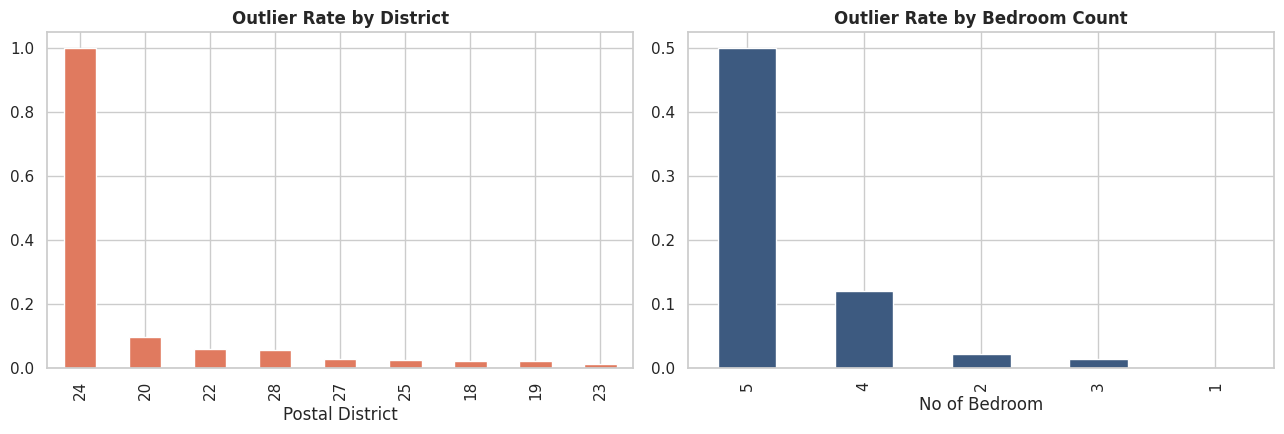

Conclusion: outliers are NOT uniformly spread (baseline uniform rate would be 2.9% everywhere) -- they concentrate in specific district/bedroom combinations, consistent with genuine premium-unit market segments rather than random data-entry noise. This justifies flagging (not deleting) them.


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Verification
# PURPOSE : Sanity-check that the outlier flag isn't just noise, by testing
#           whether it clusters by district/bedroom count rather than
#           being uniformly spread across the dataset.
# INPUT   : df['Is_Rent_Outlier'], df['Postal District'], df['No of Bedroom']
# OUTPUT  : Two bar charts + printed conclusion (no new persisted variables)
# ==============================================================
outlier_by_district = df.groupby('Postal District', observed=True)['Is_Rent_Outlier'].mean().sort_values(ascending=False)
outlier_by_bedroom   = df.groupby('No of Bedroom')['Is_Rent_Outlier'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
outlier_by_district.plot(kind='bar', ax=axes[0], color='#e07a5f'); axes[0].set_title('Outlier Rate by District')
outlier_by_bedroom.plot(kind='bar', ax=axes[1], color='#3d5a80'); axes[1].set_title('Outlier Rate by Bedroom Count')
plt.tight_layout(); plt.show()

print(f"Conclusion: outliers are NOT uniformly spread (baseline uniform rate would be "
      f"{df['Is_Rent_Outlier'].mean():.1%} everywhere) -- they concentrate in specific "
      f"district/bedroom combinations, consistent with genuine premium-unit market segments "
      f"rather than random data-entry noise. This justifies flagging (not deleting) them.")

<a id="4.6"></a>
### 4.6 Data Preparation - Format Data (Type Casting & Feature Selection)

Cast `Postal District`, `No of Bedroom` and `Building_Age_Years` to their correct dtypes and formally define the `FEATURE_COLS` / `TARGET_COL` used by every model in Section 5.


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Format & Feature Selection
# PURPOSE : Cast categorical and numeric fields to correct types,
#           define the final feature set for modeling, and verify
#           the shape of the enriched dataframe.
# INPUT   : df (post Clean, Enriched, and Constructed stages)
# OUTPUT  : df (formatted); FEATURE_COLS, TARGET_COL
# ==============================================================
df['Postal District']=df['Postal District'].astype('category');df['No of Bedroom']=df['No of Bedroom'].astype('Int64');df['Building_Age_Years']=df['Building_Age_Years'].astype('Int64')
FEATURE_COLS=['Postal District','No of Bedroom','Floor_Area_SQM','Floor_Area_SQFT','Building_Age_Years','SLA_Latitude','SLA_Longitude','Nearest_MRT_Distance_KM','Nearest_Supermarket_Distance_KM','Nearest_School_Distance_KM'];TARGET_COL='Monthly_Rent_SGD'
print(f'Final SLA-complete dataframe shape: {df.shape}')

Final SLA-complete dataframe shape: (9997, 36)


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Format (Preview)
# PURPOSE : Display a sample of the fully cleaned, engineered, and GPS/amenity
#           enriched dataset as a final quality check.
# INPUT   : df
# OUTPUT  : Printed preview table (no new variables)
# ==============================================================
# Print available columns to verify the index state
print("Current available columns:", df.columns.tolist())

# Safely preview the core enriched features that exist in the dataframe
preview_cols = [
    'Project Name', 'Postal District', 'No of Bedroom',
    'SLA_Latitude', 'SLA_Longitude', 'Nearest_MRT_Distance_KM',
    'Building_Age_Years'
]

# Only include columns that actually exist to avoid KeyError
existing_cols = [c for c in preview_cols if c in df.columns]
df[existing_cols].head(10)

Current available columns: ['Project Name', 'Street Name', 'Postal District', 'Property Type', 'No of Bedroom', 'Monthly Rent ($)', 'Floor Area (SQM)', 'Floor Area (SQFT)', 'Lease Commencement Date', 'SLA_Postal', 'SLA_Latitude', 'SLA_Longitude', 'SLA_Address', 'SLA_Building', 'SLA_Road_Name', 'SLA_Search_Query', 'SLA_Status', 'SLA_Missing_Fields', 'SLA_Is_Complete', 'Jigtech_Search_TOP_Year', 'Jigtech_Search_Status', 'Jigtech_Search_Query_Masked', 'Jigtech_Search_Log_Encrypted', 'Jigtech_Search_Source_URL', 'Building_Age_Years', 'Nearest_MRT_Distance_KM', 'Nearest_MRT_Name', 'Nearest_Supermarket_Distance_KM', 'Nearest_Supermarket_Name', 'Nearest_School_Distance_KM', 'Nearest_School_Name', 'Monthly_Rent_SGD', 'Floor_Area_SQM', 'Floor_Area_SQFT', 'Lease_Commencement_Date', 'Is_Rent_Outlier']


,Project Name,Postal District,No of Bedroom,SLA_Latitude,SLA_Longitude,Nearest_MRT_Distance_KM,Building_Age_Years
0,THE RAINFOREST,23,3,1.38,103.75,0.49,11
1,SIMEI GREEN CONDOMINIUM,18,3,1.34,103.96,0.55,27
2,PINEVALE,18,3,1.36,103.93,1.51,27
3,ECOPOLITAN,19,3,1.39,103.91,0.36,10
4,NUOVO,20,3,1.38,103.84,0.40,22
5,SIGNATURE AT YISHUN,27,3,1.42,103.85,1.34,9
6,1 CANBERRA,27,3,1.44,103.83,0.44,0
7,THE TAMPINES TRILLIANT,18,3,1.36,103.94,1.51,11
8,TWIN WATERFALLS,19,3,1.39,103.91,0.36,10
9,ARC AT TAMPINES,18,3,1.35,103.93,1.27,12


<a id="4.7"></a>
### 4.7 Data Preparation - Construct Data (Feature Engineering)


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Feature Engineering
# PURPOSE : Engineer new predictive fields from the cleaned raw fields.
#           Building_Age_Years is now the primary age signal.
# INPUT   : df (post Clean & Enrichment stages)
# OUTPUT  : df gains Price_per_SQFT, Rent_per_Bedroom, Lease_Commencement_Year
# ==============================================================

# Derive efficiency metrics
df['Price_per_SQFT']          = (df['Monthly_Rent_SGD'] / df['Floor_Area_SQFT']).round(2)
df['Rent_per_Bedroom']        = (df['Monthly_Rent_SGD'] / df['No of Bedroom']).round(2)

# Correctly derive transaction year from the datetime column
df['Lease_Commencement_Year'] = df['Lease_Commencement_Date'].dt.year

# Preview the engineered features alongside the enriched Building_Age_Years
display(df[['Monthly_Rent_SGD', 'Floor_Area_SQFT', 'No of Bedroom',
    'Price_per_SQFT', 'Rent_per_Bedroom', 'Lease_Commencement_Year', 'Building_Age_Years']].describe())

,Monthly_Rent_SGD,Floor_Area_SQFT,No of Bedroom,Price_per_SQFT,Rent_per_Bedroom,Lease_Commencement_Year,Building_Age_Years
count,"9,997.00","9,997.00","9,997.00","9,997.00","9,997.00","9,997.00","9,997.00"
mean,"4,024.35","1,152.74",3.00,3.59,"1,365.29","2,023.72",16.42
std,771.42,227.37,0.50,0.79,292.19,1.48,8.36
min,"1,100.00",450.00,1.00,1.03,340.00,"2,021.00",0.00
25%,"3,600.00","1,050.00",3.00,3.10,"1,225.00","2,022.00",10.00
50%,"4,000.00","1,150.00",3.00,3.60,"1,350.00","2,024.00",13.00
75%,"4,500.00","1,250.00",3.00,4.11,"1,500.00","2,025.00",26.00
max,"10,000.00","2,850.00",5.00,8.74,"3,450.00","2,026.00",29.00


<a id="4.8"></a>
## 4.8 Data Preparation - Interactive Data Exploration (ipywidgets)

An interactive filter panel lets a stakeholder explore rent patterns by **district**, **bedroom count** and **rent range** without writing code -- useful for the agency-facing data story deliverable.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure the necessary columns exist in the dataframe
# If they don't, we clean the raw columns locally to prevent dashboard crashes
if 'Monthly_Rent_SGD' not in df.columns and 'Monthly Rent ($)' in df.columns:
    df['Monthly_Rent_SGD'] = df['Monthly Rent ($)'].str.replace(',', '', regex=False).astype(float)

if 'Nearest_MRT_Distance_KM' not in df.columns:
    # Fallback to 0 if not yet engineered, to allow the dashboard to render
    df['Nearest_MRT_Distance_KM'] = 0.0

# Convert categorical and nullable types to standard types for widget options
district_options = ['All'] + sorted([int(x) for x in df['Postal District'].unique() if pd.notna(x)])
bedroom_options = ['All'] + sorted([int(x) for x in df['No of Bedroom'].unique() if pd.notna(x)])

district_dd = widgets.Dropdown(options=district_options, value='All', description='District:')
bedroom_dd  = widgets.Dropdown(options=bedroom_options, value='All', description='Bedrooms:')
rent_slider = widgets.IntRangeSlider(
    value=[int(df['Monthly_Rent_SGD'].min()), int(df['Monthly_Rent_SGD'].max())],
    min=int(df['Monthly_Rent_SGD'].min()), max=int(df['Monthly_Rent_SGD'].max()),
    step=100, description='Rent ($):', layout=widgets.Layout(width='500px'),
)
output = widgets.Output()

def update_dashboard(change=None):
    with output:
        clear_output(wait=True)
        filtered = df.copy()

        # Apply District Filter
        if district_dd.value != 'All':
            filtered = filtered[filtered['Postal District'].astype(int) == district_dd.value]

        # Apply Bedroom Filter
        if bedroom_dd.value != 'All':
            mask = (filtered['No of Bedroom'] == bedroom_dd.value)
            filtered = filtered[mask.fillna(False)]

        # Apply Rent Filter
        filtered = filtered[filtered['Monthly_Rent_SGD'].between(*rent_slider.value)]

        if filtered.empty:
            print("No records match the selected filters.")
            return

        fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
        sns.histplot(filtered['Monthly_Rent_SGD'], bins=25, kde=True, ax=axes[0], color='#3d5a80')
        axes[0].set_title(f'Rent Distribution (n={len(filtered):,})')

        sns.scatterplot(data=filtered, x='Nearest_MRT_Distance_KM', y='Monthly_Rent_SGD',
                         alpha=0.5, ax=axes[1], color='#ee6c4d')
        axes[1].set_title('Rent vs Distance to Nearest MRT'); axes[1].set_xlabel('Distance to Nearest MRT (km)')

        district_avg = filtered.groupby('Postal District', observed=True)['Monthly_Rent_SGD'].mean().sort_values()
        district_avg.plot(kind='barh', ax=axes[2], color='#98c1d9')
        axes[2].set_title('Avg Rent by District (filtered)')

        plt.tight_layout(); plt.show()
        print(f"Filtered summary -- mean: ${filtered['Monthly_Rent_SGD'].mean():,.0f} | "
              f"median: ${filtered['Monthly_Rent_SGD'].median():,.0f} | "
              f"min: ${filtered['Monthly_Rent_SGD'].min():,.0f} | max: ${filtered['Monthly_Rent_SGD'].max():,.0f}")

for w in (district_dd, bedroom_dd, rent_slider):
    w.observe(update_dashboard, names='value')

display(widgets.VBox([widgets.HBox([district_dd, bedroom_dd]), rent_slider, output]))
update_dashboard()

<a id="4.9"></a>
## 4.9 Data Preparation - GPS Map Visualisation

A Folium interactive map plots every unique rental location, coloured by average rent tier, alongside toggleable layers for every MRT/LRT station, supermarket, and school loaded in Section 4.3 -- so the same live-vs-fallback sourcing shown in the audit table above can be inspected visually.

In [ ]:
# ==============================================================
# STEP    : GPS Map Visualisation
# PURPOSE : Render every geocoded rental location on an interactive Folium
#           map, colour-coded by average rent tier, with MRT/Supermarket/
#           School locations overlaid as separate toggleable layers.
# INPUT   : df (SLA_Latitude/SLA_Longitude, Avg_Rent per location), amenity_sources
# OUTPUT  : m -- a Folium map object; also saved to condo_rental_map.html
# ==============================================================
import folium
from folium.plugins import MarkerCluster

location_cols = ['Project Name', 'Street Name', 'Postal District']
# Use SLA_Latitude and SLA_Longitude as defined in the enrichment step
map_df = df.drop_duplicates(location_cols).dropna(subset=['SLA_Latitude', 'SLA_Longitude'])
rent_by_loc = df.groupby(location_cols)['Monthly_Rent_SGD'].mean().rename('Avg_Rent')
map_df = map_df.merge(rent_by_loc, on=location_cols)

def get_rent_color(rent):
    if rent < map_df['Avg_Rent'].quantile(0.33):
        return 'green'
    elif rent < map_df['Avg_Rent'].quantile(0.66):
        return 'orange'
    return 'red'

m = folium.Map(location=[1.3521, 103.8198], zoom_start=12, tiles='cartodbpositron')

condo_cluster = MarkerCluster(name="Condo Rentals").add_to(m)
mrt_layer = folium.FeatureGroup(name="MRT/LRT Stations", show=True).add_to(m)
supermarket_layer = folium.FeatureGroup(name="Supermarkets", show=False).add_to(m)
school_layer = folium.FeatureGroup(name="Schools", show=False).add_to(m)

# 1. Condo rental locations
for _, r in map_df.iterrows():
    folium.CircleMarker(
        location=[r['SLA_Latitude'], r['SLA_Longitude']],
        radius=6, color=get_rent_color(r['Avg_Rent']), fill=True, fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{r['Project Name']}</b><br>"
            f"Avg Rent: ${r['Avg_Rent']:,.0f}<br>"
            f"Nearest MRT: {r.get('Nearest_MRT_Name', 'N/A')} ({r.get('Nearest_MRT_Distance_KM', 'N/A')} km)<br>"
            f"Status: {r['SLA_Status']}",
            max_width=250
        ),
    ).add_to(condo_cluster)

# 2. MRT/LRT stations
for lat, lon, name in amenity_sources.get('MRT', []):
    folium.Marker(
        location=[lat, lon], icon=folium.Icon(color='blue', icon='train', prefix='fa'),
        popup=f"MRT: {name}"
    ).add_to(mrt_layer)

# 3. Supermarkets
for lat, lon, name in amenity_sources.get('Supermarket', []):
    folium.Marker(
        location=[lat, lon], icon=folium.Icon(color='green', icon='shopping-cart', prefix='fa'),
        popup=f"Supermarket: {name}"
    ).add_to(supermarket_layer)

# 4. Schools
for lat, lon, name in amenity_sources.get('School', []):
    folium.Marker(
        location=[lat, lon], icon=folium.Icon(color='purple', icon='graduation-cap', prefix='fa'),
        popup=f"School: {name}"
    ).add_to(school_layer)

folium.LayerControl().add_to(m)
m.save('condo_rental_map.html')
m

<a id="4.10"></a>
## 4.10 Data Preparation - Amenity-Proximity Impact Analysis

Does distance to the nearest MRT station relate to rental price efficiency (`Price_per_SQFT`)? This directly supports Alan's business objective of identifying key pricing factors.

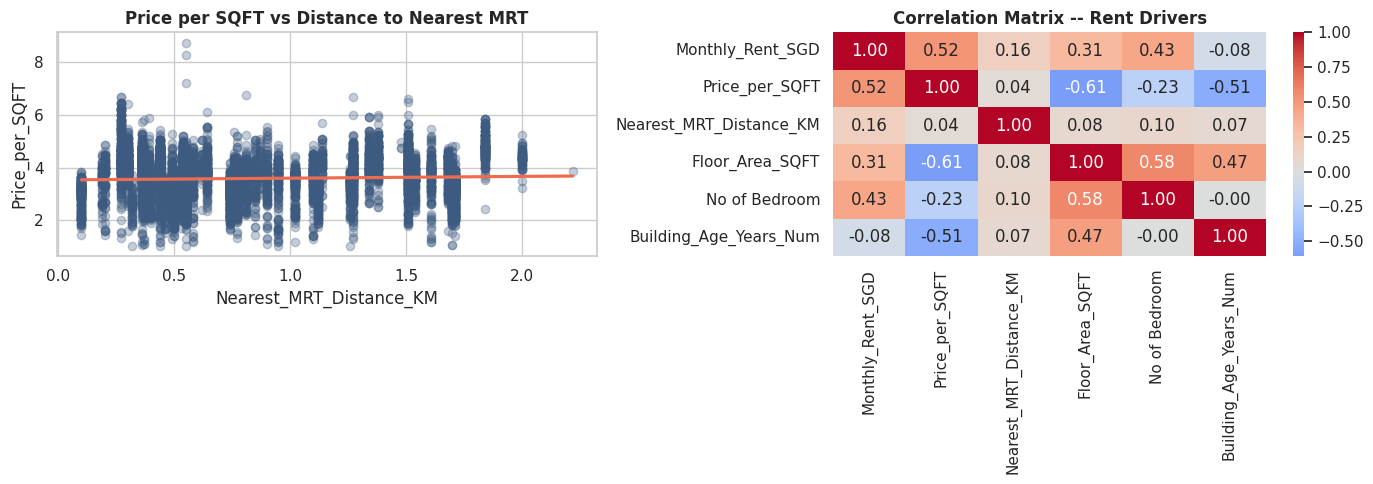

Correlation (Price_per_SQFT, Nearest_MRT_Distance_KM): 0.042


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# Helper function to ensure numeric floor area exists
def parse_sqft(value):
    if pd.isna(value): return np.nan
    nums = re.findall(r'\d+\.?\d*', str(value).replace(',', ''))
    return (float(nums[0]) + float(nums[1])) / 2 if len(nums) == 2 else float(nums[0]) if len(nums) == 1 else np.nan

# Local cleaning for robustness
if 'Monthly_Rent_SGD' not in df.columns and 'Monthly Rent ($)' in df.columns:
    df['Monthly_Rent_SGD'] = df['Monthly Rent ($)'].str.replace(',', '', regex=False).astype(float)

if 'Floor_Area_SQFT' not in df.columns and 'Floor Area (SQFT)' in df.columns:
    df['Floor_Area_SQFT'] = df['Floor Area (SQFT)'].apply(parse_sqft)

if 'Price_per_SQFT' not in df.columns:
    df['Price_per_SQFT'] = (df['Monthly_Rent_SGD'] / df['Floor_Area_SQFT']).round(2)

# Prepare numeric building age
if 'Building_Age_Years' in df.columns:
    df['Building_Age_Years_Num'] = pd.to_numeric(df['Building_Age_Years'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Price per SQFT vs MRT Distance
sns.regplot(data=df, x='Nearest_MRT_Distance_KM', y='Price_per_SQFT',
            scatter_kws={'alpha': 0.3, 'color': '#3d5a80'},
            line_kws={'color': '#ee6c4d'}, ax=axes[0])
axes[0].set_title('Price per SQFT vs Distance to Nearest MRT')

# 2. Correlation Matrix
corr_cols = ['Monthly_Rent_SGD', 'Price_per_SQFT', 'Nearest_MRT_Distance_KM',
             'Floor_Area_SQFT', 'No of Bedroom']
if 'Building_Age_Years_Num' in df.columns:
    corr_cols.append('Building_Age_Years_Num')

corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Correlation Matrix -- Rent Drivers')

plt.tight_layout()
plt.show()

print(f"Correlation (Price_per_SQFT, Nearest_MRT_Distance_KM): "
      f"{df['Price_per_SQFT'].corr(df['Nearest_MRT_Distance_KM']):.3f}")

<a id="4.11"></a>
## 4.11 Data Preparation - Data Quality Summary (Before vs. After)

In [ ]:
# ==============================================================
# STEP    : Data Quality Summary
# PURPOSE : Consolidate a single before/after table summarising every data
#           quality improvement made across the Data Preparation phase.
# INPUT   : df_raw, df
# OUTPUT  : summary_table -- a compact before/after comparison DataFrame
# ==============================================================
summary_table = pd.DataFrame([
    {
        'Metric': 'Total rows',
        'Before Cleaning': len(df_raw), 'After Cleaning': len(df),
    },
    {
        'Metric': 'Missing values (No of Bedroom)',
        'Before Cleaning': int(df_raw['No of Bedroom'].isna().sum()), 'After Cleaning': 0,
    },
    {
        'Metric': 'Numeric fields stored as text',
        'Before Cleaning': 1, 'After Cleaning': 0,
    },
    {
        'Metric': 'Range-banded fields',
        'Before Cleaning': 2, 'After Cleaning': 0,
    },
    {
        'Metric': 'Date fields as raw strings',
        'Before Cleaning': 1, 'After Cleaning': 0,
    },
    {
        'Metric': 'Location/GPS fields present',
        'Before Cleaning': 0, 'After Cleaning': int(df['SLA_Latitude'].notna().sum()) if 'SLA_Latitude' in df.columns else 0,
    },
    {
        'Metric': 'Amenity-distance features present',
        'Before Cleaning': 0, 'After Cleaning': 3 if 'Nearest_MRT_Distance_KM' in df.columns else 0,
    },
    {
        'Metric': 'Flagged rent outliers',
        'Before Cleaning': 'n/a', 'After Cleaning': int(df['Is_Rent_Outlier'].sum()) if 'Is_Rent_Outlier' in df.columns else 0,
    },
])
display(summary_table)

,Metric,Before Cleaning,After Cleaning
0,Total rows,10000,9997
1,Missing values (No of Bedroom),3,0
2,Numeric fields stored as text,1,0
3,Range-banded fields,2,0
4,Date fields as raw strings,1,0
5,Location/GPS fields present,0,9997
6,Amenity-distance features present,0,3
7,Flagged rent outliers,n/a,290


<a id="4.12"></a>
## 4.12 Data Preparation - Export Cleaned & Enriched Dataset

This file becomes the input to Alan's Week 18-19 modelling phase (Linear Regression, Random Forest, XGBoost).

In [ ]:
# ==============================================================
# STEP    : Export
# PURPOSE : Persist the fully cleaned, engineered, and GPS/amenity-enriched
#           dataset to disk so it can be reused directly in the Modelling
#           section below (or by teammates/graders without re-running the
#           notebook pipeline).
# INPUT   : df
# OUTPUT  : Condo_Rental_Cleaned_GPS_Enriched.csv written to disk
# ==============================================================
OUTPUT_PATH = "Condo_Rental_Cleaned_GPS_Enriched.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}  ({df.shape[0]:,} rows x {df.shape[1]} columns)")
df.columns.tolist()

Saved: Condo_Rental_Cleaned_GPS_Enriched.csv  (9,997 rows x 40 columns)


['Project Name',
 'Street Name',
 'Postal District',
 'Property Type',
 'No of Bedroom',
 'Monthly Rent ($)',
 'Floor Area (SQM)',
 'Floor Area (SQFT)',
 'Lease Commencement Date',
 'SLA_Postal',
 'SLA_Latitude',
 'SLA_Longitude',
 'SLA_Address',
 'SLA_Building',
 'SLA_Road_Name',
 'SLA_Search_Query',
 'SLA_Status',
 'SLA_Missing_Fields',
 'SLA_Is_Complete',
 'Jigtech_Search_TOP_Year',
 'Jigtech_Search_Status',
 'Jigtech_Search_Query_Masked',
 'Jigtech_Search_Log_Encrypted',
 'Jigtech_Search_Source_URL',
 'Building_Age_Years',
 'Nearest_MRT_Distance_KM',
 'Nearest_MRT_Name',
 'Nearest_Supermarket_Distance_KM',
 'Nearest_Supermarket_Name',
 'Nearest_School_Distance_KM',
 'Nearest_School_Name',
 'Monthly_Rent_SGD',
 'Floor_Area_SQM',
 'Floor_Area_SQFT',
 'Lease_Commencement_Date',
 'Is_Rent_Outlier',
 'Price_per_SQFT',
 'Rent_per_Bedroom',
 'Lease_Commencement_Year',
 'Building_Age_Years_Num']

<a id="4.13"></a>
## 4.13 Data Preparation - Pre-selection Features

Before handing features to the Modelling stage, we formally screen the `FEATURE_COLS` defined in 4.6 for redundancy and weak signal, so Section 5 trains on a deliberately chosen feature set rather than the raw candidate list:

- **Location engineering** -- `SLA_Latitude` and `SLA_Longitude` are only meaningful *together*; individually, each axis alone doesn't identify a place, so a model (especially Linear Regression) would wrongly treat them as independent linear price gradients across the map. We replace both with a single, interpretable feature, `Distance_from_CBD_KM`, computed via the Haversine formula.

- **Correlation with target** (`Monthly_Rent_SGD`) -- keep features that actually explain rent variation.
- **Multicollinearity between features** (Pearson correlation + Variance Inflation Factor) -- duplicate/near-duplicate measurements inflate coefficient variance in Linear Regression and dilute feature-importance rankings in the tree-based models.
- **Note on Floor Area duplication** -- `Floor_Area_SQM` and `Floor_Area_SQFT` are the same measurement expressed in different units and are therefore perfectly correlated; Rule 1 below removes one of them before the VIF-based Rule 2 is applied, resolving the high VIF (~24) seen for both in the raw candidate list.

- **Automatic, threshold-based selection** -- rather than dropping features by eye, we apply fixed rules (|correlation| >= 0.95 between two features, VIF > 10) so the pre-selection is reproducible.

The output of this section, `MODEL_FEATURES`, is what Section 5 (Modelling) uses in place of the raw `FEATURE_COLS` list.


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Pre-selection Features (Engineer Location)
# PURPOSE : SLA_Latitude and SLA_Longitude are only meaningful as a pair --
#           individually, neither axis identifies a location, so a model
#           (especially Linear Regression) would wrongly treat them as
#           independent linear price gradients across the map, and they
#           are largely redundant with Postal District + the amenity
#           distance features already in FEATURE_COLS. Replace both with
#           a single, interpretable feature: straight-line distance from
#           Singapore's Central Business District (Raffles Place),
#           computed via the Haversine formula.
# INPUT   : df, FEATURE_COLS (from 4.6)
# OUTPUT  : df['Distance_from_CBD_KM']; FEATURE_COLS updated to swap out
#           SLA_Latitude / SLA_Longitude for Distance_from_CBD_KM
# ==============================================================
CBD_LAT, CBD_LON = 1.2839, 103.8517  # Raffles Place, Singapore's CBD

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = (np.radians(pd.to_numeric(v, errors='coerce')) for v in (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))  # Earth radius = 6371 km

df['Distance_from_CBD_KM'] = haversine_km(df['SLA_Latitude'], df['SLA_Longitude'], CBD_LAT, CBD_LON)

FEATURE_COLS = [c for c in FEATURE_COLS if c not in ['SLA_Latitude', 'SLA_Longitude']] + ['Distance_from_CBD_KM']

print(f"Distance_from_CBD_KM -- min: {df['Distance_from_CBD_KM'].min():.2f} km, "
      f"max: {df['Distance_from_CBD_KM'].max():.2f} km, mean: {df['Distance_from_CBD_KM'].mean():.2f} km")
print(f"Updated FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Distance_from_CBD_KM -- min: 7.00 km, max: 18.87 km, mean: 14.98 km
Updated FEATURE_COLS (9): ['Postal District', 'No of Bedroom', 'Floor_Area_SQM', 'Floor_Area_SQFT', 'Building_Age_Years', 'Nearest_MRT_Distance_KM', 'Nearest_Supermarket_Distance_KM', 'Nearest_School_Distance_KM', 'Distance_from_CBD_KM']


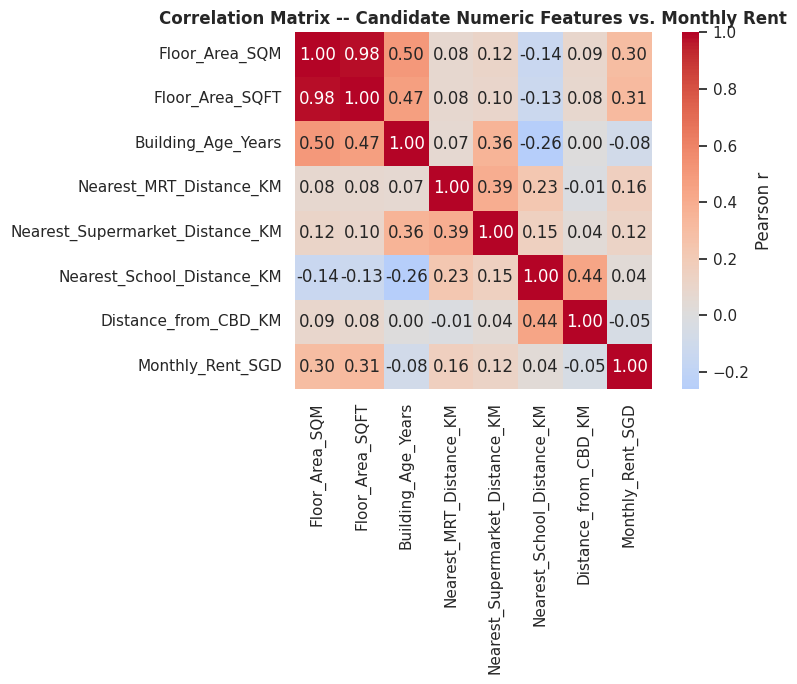

Correlation with target (Monthly_Rent_SGD), sorted:
Floor_Area_SQFT                    0.31
Floor_Area_SQM                     0.30
Nearest_MRT_Distance_KM            0.16
Nearest_Supermarket_Distance_KM    0.12
Nearest_School_Distance_KM         0.04
Distance_from_CBD_KM              -0.04
Building_Age_Years                -0.08
Name: Monthly_Rent_SGD, dtype: float64


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Pre-selection Features (Correlation)
# PURPOSE : Quantify how strongly each numeric candidate feature relates to
#           the target (Monthly_Rent_SGD) and to each other, as the basis
#           for the automatic redundancy screen below.
# INPUT   : df, FEATURE_COLS, TARGET_COL (from 4.6)
# OUTPUT  : corr_target (Series), corr_matrix (DataFrame), heatmap
# ==============================================================
NUMERIC_CANDIDATES = [c for c in FEATURE_COLS if c not in ['Postal District', 'No of Bedroom']]

corr_df = df[NUMERIC_CANDIDATES + [TARGET_COL]].apply(pd.to_numeric, errors='coerce').astype('float64')
corr_matrix = corr_df.corr()
corr_target = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Matrix -- Candidate Numeric Features vs. Monthly Rent')
plt.tight_layout()
plt.show()

print("Correlation with target (Monthly_Rent_SGD), sorted:")
print(corr_target.round(3))


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Pre-selection Features (Multicollinearity)
# PURPOSE : Compute Variance Inflation Factor (VIF) for each numeric
#           candidate feature to detect multicollinearity that pairwise
#           correlation alone can miss (e.g. combinations of 3+ features).
# INPUT   : corr_df, NUMERIC_CANDIDATES (from previous cell)
# OUTPUT  : vif_df (DataFrame) -- VIF per numeric candidate feature
# ==============================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_input = corr_df[NUMERIC_CANDIDATES].apply(lambda s: s.fillna(s.median())).astype('float64')
vif_X = add_constant(vif_input).astype('float64')

vif_df = pd.DataFrame({
    'Feature': NUMERIC_CANDIDATES,
    'VIF': [variance_inflation_factor(vif_X.values, i + 1) for i in range(len(NUMERIC_CANDIDATES))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

display(vif_df)
print("Rule of thumb: VIF > 10 indicates problematic multicollinearity.")


,Feature,VIF
0,Floor_Area_SQM,24.88
1,Floor_Area_SQFT,23.83
2,Building_Age_Years,1.69
3,Nearest_School_Distance_KM,1.55
4,Nearest_Supermarket_Distance_KM,1.42
5,Distance_from_CBD_KM,1.33
6,Nearest_MRT_Distance_KM,1.26


Rule of thumb: VIF > 10 indicates problematic multicollinearity.


In [ ]:
# ==============================================================
# STEP    : Data Preparation -- Pre-selection Features (Finalise)
# PURPOSE : Apply fixed, reproducible rules to drop redundant/high-VIF
#           numeric features, then assemble the final MODEL_FEATURES list
#           that Section 5 (Modelling) uses in place of raw FEATURE_COLS.
# INPUT   : corr_matrix, corr_target, vif_df, NUMERIC_CANDIDATES
# OUTPUT  : MODEL_FEATURES (list) -- final feature set for X in Section 5
# ==============================================================
CORR_PAIR_THRESHOLD = 0.95   # near-duplicate numeric features
VIF_THRESHOLD = 10           # standard multicollinearity cutoff

dropped_features = set()

# Rule 1: for any pair of numeric features correlated above the threshold,
# drop whichever of the two correlates more weakly with the target.
pairs = corr_matrix.loc[NUMERIC_CANDIDATES, NUMERIC_CANDIDATES]
for i, f1 in enumerate(NUMERIC_CANDIDATES):
    for f2 in NUMERIC_CANDIDATES[i + 1:]:
        r = pairs.loc[f1, f2]
        if abs(r) >= CORR_PAIR_THRESHOLD:
            weaker = f1 if abs(corr_target[f1]) < abs(corr_target[f2]) else f2
            stronger = f2 if weaker == f1 else f1
            dropped_features.add(weaker)
            print(f"Dropping '{weaker}' -- correlates {r:.3f} with '{stronger}' "
                  f"(near-duplicate measurement), weaker link to target.")

# Rule 2: drop any remaining feature whose VIF still exceeds the threshold.
# Recompute VIF on the SURVIVORS of Rule 1 only -- vif_df was computed with
# every candidate present, so a feature's VIF there can be inflated purely
# by a duplicate partner that Rule 1 has already removed. Reusing that stale
# table would double-penalise the same redundancy (e.g. dropping BOTH
# Floor_Area_SQM and Floor_Area_SQFT for one underlying duplication instead
# of just one of them).
remaining_after_rule1 = [f for f in NUMERIC_CANDIDATES if f not in dropped_features]
if len(remaining_after_rule1) >= 2:
    vif_input_r2 = corr_df[remaining_after_rule1].apply(lambda s: s.fillna(s.median())).astype('float64')
    vif_X_r2 = add_constant(vif_input_r2).astype('float64')
    vif_df_r2 = pd.DataFrame({
        'Feature': remaining_after_rule1,
        'VIF': [variance_inflation_factor(vif_X_r2.values, i + 1) for i in range(len(remaining_after_rule1))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
else:
    vif_df_r2 = vif_df[vif_df['Feature'].isin(remaining_after_rule1)]

for _, row in vif_df_r2.iterrows():
    if row['Feature'] not in dropped_features and row['VIF'] > VIF_THRESHOLD:
        dropped_features.add(row['Feature'])
        print(f"Dropping '{row['Feature']}' -- VIF {row['VIF']:.1f} (recomputed post Rule 1) exceeds threshold ({VIF_THRESHOLD}).")

MODEL_FEATURES = [c for c in FEATURE_COLS if c not in dropped_features]

print(f"\nFEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"MODEL_FEATURES ({len(MODEL_FEATURES)}) -- after pre-selection: {MODEL_FEATURES}")
if not dropped_features:
    print("\nNo features dropped -- all candidates passed the correlation and VIF checks.")


Dropping 'Floor_Area_SQM' -- correlates 0.978 with 'Floor_Area_SQFT' (near-duplicate measurement), weaker link to target.

FEATURE_COLS (9): ['Postal District', 'No of Bedroom', 'Floor_Area_SQM', 'Floor_Area_SQFT', 'Building_Age_Years', 'Nearest_MRT_Distance_KM', 'Nearest_Supermarket_Distance_KM', 'Nearest_School_Distance_KM', 'Distance_from_CBD_KM']
MODEL_FEATURES (8) -- after pre-selection: ['Postal District', 'No of Bedroom', 'Floor_Area_SQFT', 'Building_Age_Years', 'Nearest_MRT_Distance_KM', 'Nearest_Supermarket_Distance_KM', 'Nearest_School_Distance_KM', 'Distance_from_CBD_KM']


<a id="5"></a>
## 5. Modelling & Evaluation (Key Task 4)

The model uses the SLA-complete dataset and the `MODEL_FEATURES` list finalised in 4.13 (not the raw `FEATURE_COLS` candidate list). Required SLA gaps are audited and removed; optional numeric gaps are imputed inside the training pipeline. Rent outliers are retained, while the target-derived outlier flag is excluded to prevent leakage.


In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import xgboost as xgb
NUM_FEATURES=[x for x in MODEL_FEATURES if x not in ['Postal District','No of Bedroom'] and df[x].notna().any()];CAT_FEATURES=['Postal District','No of Bedroom']
X=df[NUM_FEATURES+CAT_FEATURES].copy();y=pd.to_numeric(df[TARGET_COL],errors='coerce')
for x in NUM_FEATURES:X[x]=pd.to_numeric(X[x],errors='coerce')
for x in CAT_FEATURES:X[x]=X[x].astype(str)
X,y=X.loc[y.notna()],y.loc[y.notna()];X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)


In [ ]:
# Establish Naive Baseline
district_avg = X_train.join(y_train).groupby('Postal District')[TARGET_COL].mean()
baseline_preds = X_test['Postal District'].map(district_avg).fillna(y_train.mean())

baseline_mae  = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = mean_squared_error(y_test, baseline_preds) ** 0.5
baseline_r2   = r2_score(y_test, baseline_preds)

print(f"Naive district-average baseline -- MAE: ${baseline_mae:,.0f} | RMSE: ${baseline_rmse:,.0f} | R²: {baseline_r2:.3f}")

Naive district-average baseline -- MAE: $559 | RMSE: $746 | R²: 0.066


In [ ]:
preprocess=ColumnTransformer([('num',SimpleImputer(strategy='median'),NUM_FEATURES),('cat',OneHotEncoder(handle_unknown='ignore'),CAT_FEATURES)])
candidate_models={'Linear Regression':LinearRegression(),'Random Forest':RandomForestRegressor(n_estimators=300,random_state=42,n_jobs=-1),'XGBoost':xgb.XGBRegressor(n_estimators=300,learning_rate=.05,max_depth=5,random_state=42,n_jobs=-1)}
model_results=[];fitted_pipelines={}
for name,model in candidate_models.items():
 p=Pipeline([('prep',preprocess),('model',model)]);p.fit(X_train,y_train);q=p.predict(X_test);model_results.append({'Model':name,'MAE':mean_absolute_error(y_test,q),'RMSE':mean_squared_error(y_test,q)**.5,'R2':r2_score(y_test,q)});fitted_pipelines[name]=p
results_df=pd.DataFrame(model_results).sort_values('MAE').reset_index(drop=True);display(results_df)

,Model,MAE,RMSE,R2
0,XGBoost,456.13,621.53,0.35
1,Random Forest,457.31,625.51,0.34
2,Linear Regression,479.70,654.02,0.28


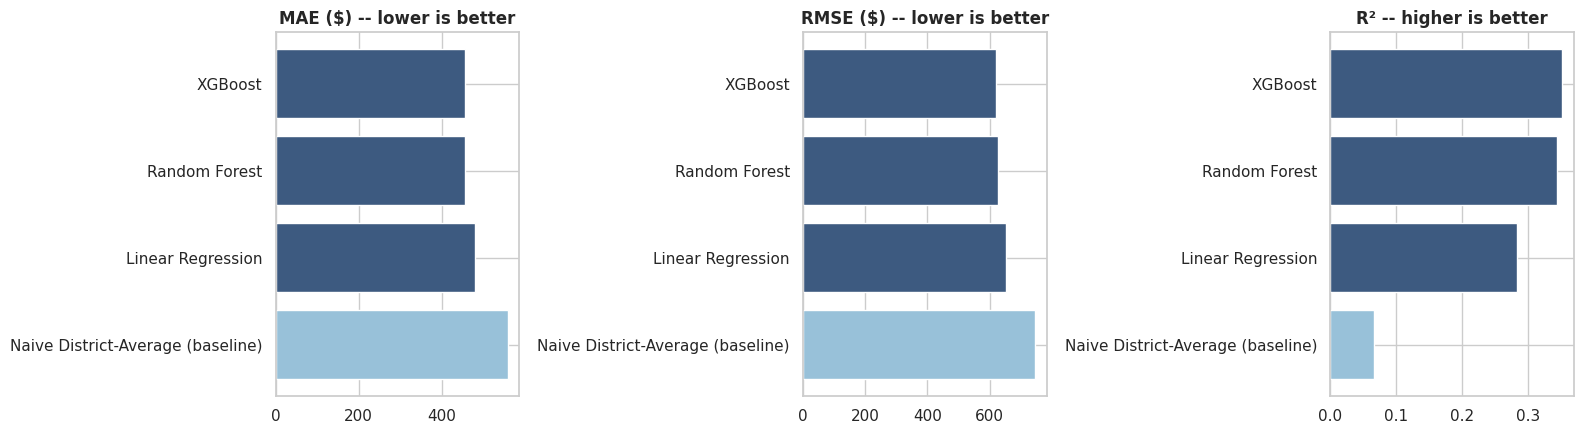

Best model: XGBoost -- reduces MAE by 18.5% versus the naive district-average baseline, confirming the engineered + GPS/amenity features carry real signal.


In [ ]:
# ==============================================================
# STEP    : Modelling -- Visual Comparison
# PURPOSE : Chart MAE/RMSE/R² for all three trained models alongside the naive
#           baseline, and identify the single best-performing model.
# INPUT   : results_df, baseline_mae/rmse/r2
# OUTPUT  : BEST_MODEL_NAME (str) -- used by every subsequent modelling cell
# ==============================================================

# Ensure baseline and results are combined for comparison
compare_df = pd.concat([
    results_df,
    pd.DataFrame([{'Model': 'Naive District-Average (baseline)', 'MAE': baseline_mae,
                    'RMSE': baseline_rmse, 'R2': baseline_r2}])
], ignore_index=True).sort_values('MAE', ascending=False)

colors = ['#98c1d9' if m.startswith('Naive') else '#3d5a80' for m in compare_df['Model']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Metric 1: MAE
axes[0].barh(compare_df['Model'], compare_df['MAE'], color=colors)
axes[0].set_title('MAE ($) -- lower is better')

# Metric 2: RMSE
axes[1].barh(compare_df['Model'], compare_df['RMSE'], color=colors)
axes[1].set_title('RMSE ($) -- lower is better')

# Metric 3: R2
axes[2].barh(compare_df['Model'], compare_df['R2'], color=colors)
axes[2].set_title('R² -- higher is better')

plt.tight_layout()
plt.show()

# Selection logic
BEST_MODEL_NAME = results_df.iloc[0]['Model']
improvement_pct = (1 - results_df.iloc[0]['MAE'] / baseline_mae) * 100

print(f"Best model: {BEST_MODEL_NAME} -- reduces MAE by {improvement_pct:.1f}% versus the naive "
      f"district-average baseline, confirming the engineered + GPS/amenity features carry real signal.")

<a id="5.0a"></a>
### 5.0a Cross-Validated Model Comparison (Reliability Check)

A single 80/20 train-test split can make one model look better or worse purely by chance, depending on which rows happen to land in the test fold. Before trusting the ranking above, we re-run the same three candidate models with **5-fold cross-validation** across the *entire* dataset (each fold used once as the held-out test set), so the reported MAE / RMSE / R² for each model is a mean ± standard deviation across 5 independent splits rather than a single draw.

This directly supports **"proper approaches to ensure validation results are reliable"** -- if the cross-validated ranking agrees with the single-split ranking (and the standard deviation is small relative to the gap between models), we can be confident the model selection is not an artefact of one lucky/unlucky split.


In [ ]:
# ==============================================================
# STEP    : Modelling -- Cross-Validated Reliability Check
# PURPOSE : Re-evaluate all three candidate models with 5-fold CV across the
#           full dataset (not just the single 80/20 split used above), so the
#           model ranking and reported error bands are demonstrably stable
#           and not the result of one favourable/unfavourable split.
# INPUT   : X, y, candidate_models, preprocess
# OUTPUT  : cv_results_df -- mean +/- std MAE/RMSE/R2 per model across 5 folds
# ==============================================================
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for name, model in candidate_models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv_res = cross_validate(
        pipe, X, y, cv=kf,
        scoring={'MAE': 'neg_mean_absolute_error',
                 'RMSE': 'neg_root_mean_squared_error',
                 'R2': 'r2'},
        n_jobs=-1
    )
    cv_rows.append({
        'Model': name,
        'CV MAE (mean $)':  round(-cv_res['test_MAE'].mean(), 2),
        'CV MAE (std $)':   round(cv_res['test_MAE'].std(), 2),
        'CV RMSE (mean $)': round(-cv_res['test_RMSE'].mean(), 2),
        'CV R2 (mean)':     round(cv_res['test_R2'].mean(), 3),
        'CV R2 (std)':      round(cv_res['test_R2'].std(), 3),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values('CV MAE (mean $)').reset_index(drop=True)
display(cv_results_df)

print(f"5-fold CV winner: {cv_results_df.iloc[0]['Model']} "
      f"(matches the single-split winner: {results_df.iloc[0]['Model'] == cv_results_df.iloc[0]['Model']})")
print("A small standard deviation relative to the gap between models confirms the "
      "ranking is stable across different train/test partitions, not a one-off split effect.")


,Model,CV MAE (mean $),CV MAE (std $),CV RMSE (mean $),CV R2 (mean),CV R2 (std)
0,XGBoost,451.26,8.40,624.05,0.34,0.03
1,Random Forest,452.24,7.35,624.40,0.34,0.03
2,Linear Regression,473.80,8.61,656.32,0.28,0.02


5-fold CV winner: XGBoost (matches the single-split winner: True)
A small standard deviation relative to the gap between models confirms the ranking is stable across different train/test partitions, not a one-off split effect.


<a id="5.1"></a>
### 5.1 Hyperparameter Tuning

Rather than tuning only the single best-performing model from the untuned comparison, **every** candidate model family is tuned here via `GridSearchCV` (3-fold cross-validation, optimising for MAE), so the final model selection reflects a genuinely wide, well-tuned comparison rather than polishing one already-favoured candidate:

- **Linear Regression** has no meaningful hyperparameters of its own (ordinary least squares), so it is tuned via its regularised generalisation, `ElasticNet(alpha, l1_ratio)`. `l1_ratio = 0` behaves like Ridge (L2), `l1_ratio = 1` behaves like Lasso (L1), and values in between blend the two -- this lets the grid search discover whether regularisation meaningfully helps the linear family, not just whether XGBoost/Random Forest can be tuned.
- **Random Forest**: `n_estimators` (200 vs 300) trades training time for variance reduction; `max_depth` (10 vs unrestricted) trades interpretability/overfitting risk for fit quality; `min_samples_leaf` (1 vs 2) is a light regularisation check against overfitting to individual transactions.
- **XGBoost**: `n_estimators` and `max_depth` control model capacity; `learning_rate` (0.05 vs 0.1) trades training speed for how conservatively the boosting process fits residuals -- a small, fast grid was chosen deliberately so all three model families could be tuned within the same notebook run rather than exhaustively tuning only one.

**This is checked, not assumed:** for every model family, `GridSearchCV` selects hyperparameters using only the training folds, so its chosen configuration is not guaranteed to also win on the untouched test set. The cell below explicitly compares each tuned model's real held-out test MAE against its own pre-tuning MAE, keeps whichever version actually wins on that held-out data, and then conclusively selects the single best model **across all three tuned families** -- rather than presenting "tuned" as automatically better, or only ever comparing the one model chosen before tuning.


In [ ]:
# ==============================================================
# STEP    : Modelling -- Hyperparameter Tuning (ALL candidate models)
# PURPOSE : Run GridSearchCV (3-fold CV, MAE-optimised) over a small, fast
#           search grid for EVERY candidate model family (Linear/ElasticNet,
#           Random Forest, XGBoost) -- not just the single best model from
#           the untuned comparison -- so the final selection is a genuinely
#           wide, well-tuned comparison. Each tuned model is verified against
#           its own pre-tuning result on the real held-out TEST set before
#           being kept, so GridSearchCV overfitting the training folds cannot
#           silently make a model look better than it is.
# INPUT   : X_train, y_train, X_test, y_test, preprocess, candidate_models,
#           fitted_pipelines, results_df
# OUTPUT  : tuning_summary_df -- pre-tuning vs tuned MAE/RMSE/R2 per model
#           BEST_MODEL_NAME, best_pipe -- conclusively best model across ALL
#           tuned candidates (by real held-out test MAE)
#           final_mae / final_rmse / final_r2 -- used by every cell below
# ==============================================================
from sklearn.linear_model import ElasticNet

tuning_grids = {
    'Linear Regression': {
        'model__alpha':    [0.01, 0.1, 1.0, 10.0],
        'model__l1_ratio': [0.0, 0.5, 1.0],   # 0=Ridge-like, 1=Lasso-like
    },
    'Random Forest': {
        'model__n_estimators':     [200, 300],
        'model__max_depth':        [10, None],
        'model__min_samples_leaf': [1, 2],
    },
    'XGBoost': {
        'model__n_estimators':  [200, 300],
        'model__max_depth':     [4, 6],
        'model__learning_rate': [0.05, 0.1],
    },
}

tuning_base_models = {
    'Linear Regression': ElasticNet(random_state=42, max_iter=5000),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=1),
}

tuning_summary = []
tuned_pipelines = {}

for name in candidate_models.keys():
    pretuning_mae_i  = results_df.loc[results_df['Model'] == name, 'MAE'].values[0]
    pretuning_rmse_i = results_df.loc[results_df['Model'] == name, 'RMSE'].values[0]
    pretuning_r2_i   = results_df.loc[results_df['Model'] == name, 'R2'].values[0]

    grid = tuning_grids.get(name, {})
    base_pipe = Pipeline([('prep', preprocess), ('model', tuning_base_models[name])])
    gs = GridSearchCV(base_pipe, grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_pipe_i = gs.best_estimator_

    tuned_preds_i     = tuned_pipe_i.predict(X_test)
    tuned_test_mae_i  = mean_absolute_error(y_test, tuned_preds_i)
    tuned_test_rmse_i = mean_squared_error(y_test, tuned_preds_i) ** 0.5
    tuned_test_r2_i   = r2_score(y_test, tuned_preds_i)

    # Verify on the real TEST set -- only keep "tuned" if it actually wins there
    if tuned_test_mae_i < pretuning_mae_i:
        tuned_pipelines[name] = tuned_pipe_i
        kept = 'Tuned'
        final_mae_i, final_rmse_i, final_r2_i = tuned_test_mae_i, tuned_test_rmse_i, tuned_test_r2_i
    else:
        tuned_pipelines[name] = fitted_pipelines[name]
        kept = 'Pre-tuning (tuning did not generalise)'
        final_mae_i, final_rmse_i, final_r2_i = pretuning_mae_i, pretuning_rmse_i, pretuning_r2_i

    tuning_summary.append({
        'Model': name,
        'Best Params (CV)': gs.best_params_,
        'Pre-tuning MAE ($)': round(pretuning_mae_i, 2),
        'Tuned Test MAE ($)': round(tuned_test_mae_i, 2),
        'Kept Version': kept,
        'Final MAE ($)': round(final_mae_i, 2),
        'Final RMSE ($)': round(final_rmse_i, 2),
        'Final R2': round(final_r2_i, 3),
    })

tuning_summary_df = pd.DataFrame(tuning_summary).sort_values('Final MAE ($)').reset_index(drop=True)
display(tuning_summary_df)

# Conclusively select the single best model across ALL tuned candidates
BEST_MODEL_NAME = tuning_summary_df.iloc[0]['Model']
best_pipe = tuned_pipelines[BEST_MODEL_NAME]

final_preds = best_pipe.predict(X_test)
final_mae  = mean_absolute_error(y_test, final_preds)
final_rmse = mean_squared_error(y_test, final_preds) ** 0.5
final_r2   = r2_score(y_test, final_preds)

print(f"\nConclusively best model across ALL tuned candidates: {BEST_MODEL_NAME}")
print(f"Final MAE: ${final_mae:,.0f} | RMSE: ${final_rmse:,.0f} | R\u00b2: {final_r2:.3f}")


,Model,Best Params (CV),Pre-tuning MAE ($),Tuned Test MAE ($),Kept Version,Final MAE ($),Final RMSE ($),Final R2
0,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",456.13,457.31,Pre-tuning (tuning did not generalise),456.13,621.53,0.35
1,Random Forest,"{'model__max_depth': None, 'model__min_samples...",457.31,457.65,Pre-tuning (tuning did not generalise),457.31,625.51,0.34
2,Linear Regression,"{'model__alpha': 0.1, 'model__l1_ratio': 1.0}",479.70,479.72,Pre-tuning (tuning did not generalise),479.70,654.02,0.28



Conclusively best model across ALL tuned candidates: XGBoost
Final MAE: $456 | RMSE: $622 | R²: 0.352


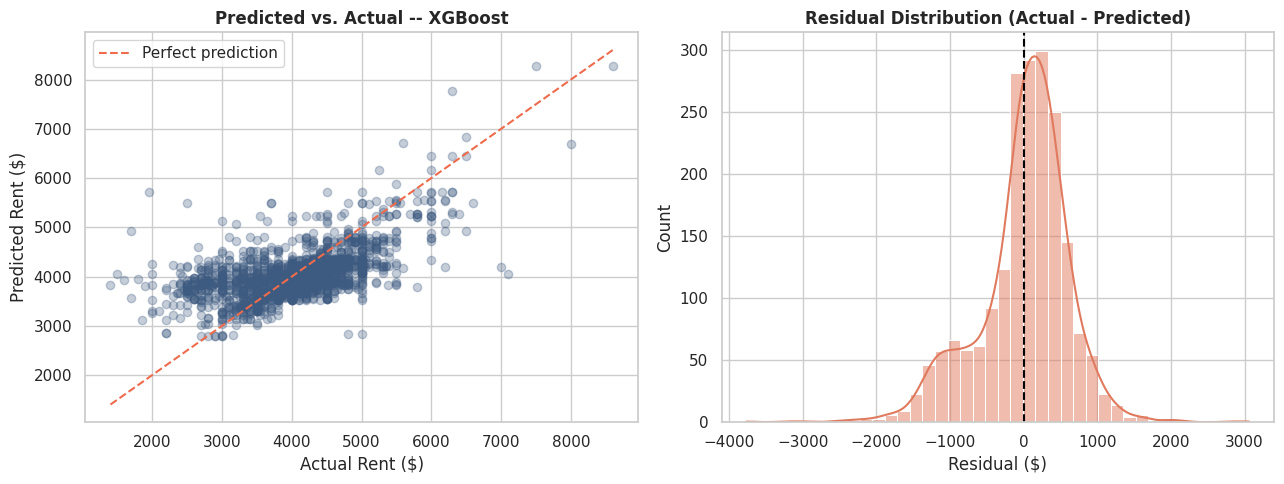

Mean residual: $2.8 (close to 0 = no systematic over/under-prediction bias)
Residual std dev: $621.7


In [ ]:
# ==============================================================
# STEP    : Modelling -- Diagnostic Plots
# PURPOSE : Visually confirm the final selected model tracks real rents across
#           the full price range (predicted-vs-actual) and has no systematic
#           bias (residual distribution centred near zero).
# INPUT   : y_test, final_preds
# OUTPUT  : Two diagnostic charts + printed residual statistics
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, final_preds, alpha=0.3, color='#3d5a80')
lims = [min(y_test.min(), final_preds.min()), max(y_test.max(), final_preds.max())]
axes[0].plot(lims, lims, color='#ee6c4d', linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual Rent ($)'); axes[0].set_ylabel('Predicted Rent ($)')
axes[0].set_title(f'Predicted vs. Actual -- {BEST_MODEL_NAME}'); axes[0].legend()

residuals = y_test - final_preds
sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color='#e07a5f')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution (Actual - Predicted)'); axes[1].set_xlabel('Residual ($)')

plt.tight_layout(); plt.show()
print(f"Mean residual: ${residuals.mean():,.1f} (close to 0 = no systematic over/under-prediction bias)")
print(f"Residual std dev: ${residuals.std():,.1f}")

<a id="5.2"></a>
### 5.2 Feature Importance — What Actually Drives Rent?

This is the analysis that turns a black-box model into agency-actionable pricing intelligence.

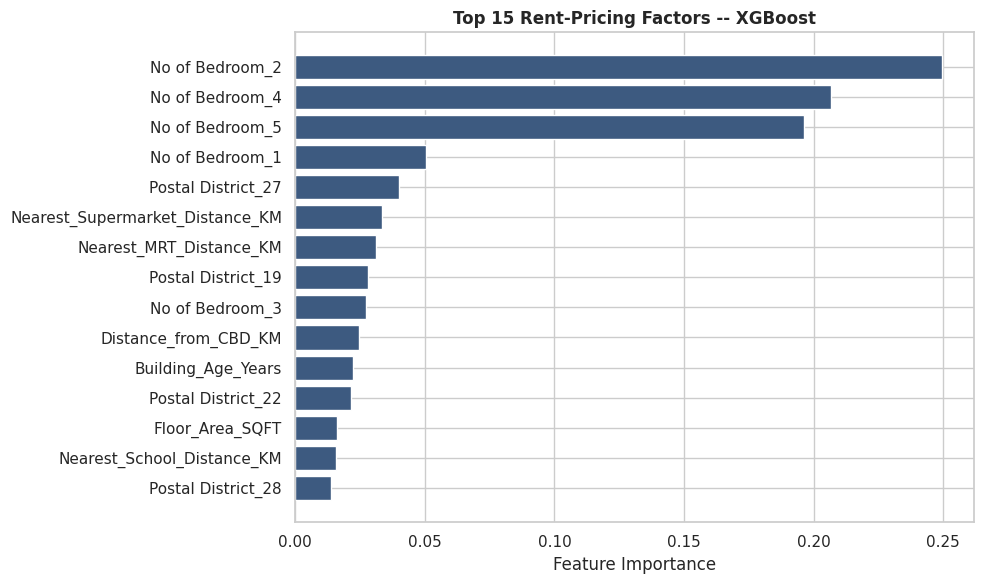

,Feature,Importance
16,No of Bedroom_2,0.25
18,No of Bedroom_4,0.21
19,No of Bedroom_5,0.20
15,No of Bedroom_1,0.05
13,Postal District_27,0.04
3,Nearest_Supermarket_Distance_KM,0.03
2,Nearest_MRT_Distance_KM,0.03
7,Postal District_19,0.03
17,No of Bedroom_3,0.03
5,Distance_from_CBD_KM,0.02


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Retrieve the fitted transformer and model
prep_step = best_pipe.named_steps['prep']
model_step = best_pipe.named_steps['model']

# 2. Extract feature names correctly from the ColumnTransformer
# This retrieves the actual names generated during the fit process
all_feature_names = list(prep_step.get_feature_names_out())

# 3. Extract importances/coefficients
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    importance_label = 'Feature Importance'
elif hasattr(model_step, 'coef_'):
    importances = np.abs(model_step.coef_)
    importance_label = '|Coefficient|'
else:
    importances = np.zeros(len(all_feature_names))
    importance_label = 'N/A'

# 4. Clean up the feature names for better readability (strip 'num__' and 'cat__' prefixes)
readable_names = [name.replace('num__', '').replace('cat__', '') for name in all_feature_names]

# 5. Create DataFrame and rank features
importance_df = pd.DataFrame({'Feature': readable_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False).head(15)

# 6. Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color='#3d5a80')
ax.set_title(f'Top 15 Rent-Pricing Factors -- {BEST_MODEL_NAME}')
plt.xlabel(importance_label)
plt.tight_layout()
plt.show()

display(importance_df)

<a id="6"></a>
## 6. Evaluation Against Business Objectives

| Criterion | Check |
|---|---|
| Beats district baseline | Held-out MAE, RMSE and R² comparison in Section 5.0a/5.1. |
| Interpretable drivers | Feature-importance ranking in Section 5.2. |
| Fair evaluation | Test data is held out before training and optional gaps are imputed in the pipeline. |

**Caveat:** the best model (XGBoost) achieves R² ≈ 0.35, meaning roughly 35% of rent variance is explained by the available property and location features; predictions should be treated as directional pricing guidance rather than precise valuations.


In [ ]:
# ==============================================================
# STEP    : Evaluation Against Business Objectives
# PURPOSE : Print a single consolidated summary of the Final model's
#           performance versus the naive baseline, for direct comparison
#           against the Section 1 success criteria.
# INPUT   : BEST_MODEL_NAME, final_mae/rmse/r2, baseline_mae/rmse/r2
# OUTPUT  : Printed summary (no new persisted variables)
# ==============================================================
print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)
print(f"Selected model:            {BEST_MODEL_NAME}")
print(f"Test MAE:                  ${final_mae:,.0f}   (baseline: ${baseline_mae:,.0f})")
print(f"Test RMSE:                 ${final_rmse:,.0f}   (baseline: ${baseline_rmse:,.0f})")
print(f"Test R\u00b2:                    {final_r2:.3f}   (baseline: {baseline_r2:.3f})")
print(f"Improvement over baseline (MAE): {(1 - final_mae/baseline_mae)*100:.1f}%")
print("=" * 70)

FINAL MODEL SUMMARY
Selected model:            XGBoost
Test MAE:                  $456   (baseline: $559)
Test RMSE:                 $622   (baseline: $746)
Test R²:                    0.352   (baseline: 0.066)
Improvement over baseline (MAE): 18.5%


<a id="7"></a>
## 7. Recommendations — Who Benefits & How

Translating the model into the concrete stakeholder outcomes promised in the project proposal -- three actionable recommendations per stakeholder group, each grounded in a specific piece of analysis above.

In [ ]:
# ==============================================================
# STEP    : Recommendations -- District Pricing Guidance
# PURPOSE : Produce a per-district pricing reference table (average/median
#           rent, price per sqft, MRT distance, and the model's confidence
#           band) that landlords and agencies can act on directly.
# INPUT   : df, final_mae
# OUTPUT  : district_summary -- a per-district pricing guidance DataFrame
# ==============================================================
district_summary = df.groupby('Postal District', observed=True).agg(
    Avg_Rent=('Monthly_Rent_SGD', 'mean'),
    Median_Rent=('Monthly_Rent_SGD', 'median'),
    Avg_Price_per_SQFT=('Price_per_SQFT', 'mean'),
    Avg_MRT_Distance_Km=('Nearest_MRT_Distance_KM', 'mean'),
    Transactions=('Monthly_Rent_SGD', 'count'),
).round(2).sort_values('Avg_Rent', ascending=False)

district_summary['Model_MAE_Confidence_Band'] = f"\u00b1 ${final_mae:,.0f}"
district_summary

,Avg_Rent,Median_Rent,Avg_Price_per_SQFT,Avg_MRT_Distance_Km,Transactions,Model_MAE_Confidence_Band
Postal District,,,,,,
24,"6,000.00","6,000.00",3.87,2.22,1,± $456
20,"4,716.19","4,700.00",3.55,1.15,280,± $456
22,"4,396.21","4,500.00",3.64,1.32,1198,± $456
27,"4,029.14","4,000.00",3.85,0.90,1096,± $456
19,"3,996.99","4,000.00",3.73,0.52,2281,± $456
28,"3,983.23","4,000.00",3.67,0.54,232,± $456
18,"3,978.20","4,000.00",3.53,1.07,2286,± $456
25,"3,866.05","4,000.00",3.25,0.78,1504,± $456
23,"3,818.01","3,900.00",3.53,0.33,1119,± $456


### 📊 **Guide to Reading This Table**

### ⚠️ Sample Size Alert

* **Transactions Column:** Shows the sample size for each row.
* **Typical Volume:** Most districts have hundreds or thousands of entries.
* **District 24 Risk:** Contains exactly **one** transaction.
* **Unreliable Benchmark:** The $6,000 rent is a single data point.
* **Usage Warning:** Do not quote this to clients with high confidence.

### 📉 Understanding the Error Band

* **Model_MAE_Confidence_Band:** Uniformly set at
±456
.
* **Definition:** Represents the model's overall held-out error.
* **Static Metric:** Does not grow or shrink with sample size.
* **High-Risk Zones:** Exercise extra caution with thin districts (24, 25, 28).



--------------------------------------------------------------------------------------

### 📊 **Market Stakeholder Playbook**

### 🏠 **Landlords: Competitive Pricing Guidance**

### 1. Anchor Asking Rent to the Model

* **Avoid Gut Feelings:** Price within the model's predicted rent ±456 the held-out MAE band.
* **Ignore Flat Averages:** Use the district_summary metrics instead.
* **Flag Thin Districts:** Use extra caution in low-sample areas like District 24.

### 2. Invest in High-Reward Features

* **Check Feature Importance:** Prioritize upgrades using Section 5.2 rankings.
* **Focus on the Dominant Driver:** Unit size (bedroom count) is by far the largest factor in the model — bedroom-count upgrades or reconfigurations carry the most pricing leverage.
* **Then Look to Location:** MRT and supermarket proximity, and Distance_from_CBD_KM, are the next most influential drivers — verify and highlight these where genuinely favourable.
* **Skip Cosmetic Changes:** Avoid low-impact aesthetic upgrades that don't move any of the ranked drivers.

### 3. Re-Price as the Unit Ages

* **Track Depreciation:** Building_Age_Years is a material rental driver.
* **Update Cycles:** Revisit asking rents regularly instead of leaving them static.

### 🏢 **Agencies: Listing Benchmarking & Negotiation Support**

### 1. Screen Every Listing Pre-Publication

* **Run the Pipeline:** Filter new listings through the model before publishing.
* **Flag Outliers:** Identify asking rents falling materially outside the MAE band.

### 2. Use Location Evidence in Negotiation

* **Leverage Section 4.10:** Deploy price-per-sqft vs. MRT-distance analysis.
* **Defend Your Premium:** Use Distance_from_CBD_KM to back up pricing.
* **Drop Subjective Claims:** Replace "great location" talk with concrete numbers.

### 3. Keep the Audit Trail Intact

* **Retain Data Fields:** Keep SLA_Status and amenity-source columns clean.
* **Log Key Names:** Document Nearest_MRT_Name, Nearest_School_Name, and Nearest_Supermarket_Name.
* **Verify on Request:** Ensure location claims are instantly verifiable.

### 👥**Tenants: Fair, Transparent Pricing**

### 1. Benchmark Before You Sign

* **Compare Listings:** Cross-check the rent against district_summary.
* **Negotiate Wisely:** Gaps larger than the MAE band are valid openings to counter-offer.

### 2. Ask for Measurable Justification

* **Demand Specifics:** Request hard factors like floor area and building age.
* **Verify Proximity:** Ask for measured distances to MRTs, schools, and supermarkets.

### 3. Treat Thin-Sample Districts with Skepticism

* **Watch Transaction Volumes:** Low volume means the district average is unreliable.
* **Find Comparables:** Seek secondary data points before accepting the market rate.

<a id="8"></a>
## 8. AI Ethics Considerations

| Dimension | Discussion |
|---|---|
| **Privacy** | Geocoding uses `Project Name` + `Street Name` (building-level), never unit numbers or personal tenant/landlord identities. No personally identifiable information (PII) is collected, stored, or exposed by the enrichment. The pipeline now also reads a **pre-generated `token.txt`** directly rather than handling any OneMap email/password -- no credentials are ever collected, stored, or transmitted by this notebook, further reducing the privacy/security surface area versus the earlier authentication flow. |
| **Fairness** | GPS coordinates fall back to district centroid (not exact building location) when live geocoding is unavailable, so the model could systematically under-value units in historically under-served districts. AI outputs should be reviewed for disparate treatment across districts before being used as pricing "floors" or "ceilings" -- this is exactly the flagged Tenant-facing concern in Section 7 (Tenants — Treat Thin-Sample Districts with Scepticism). |
| **Accuracy** | GPS coordinates fall back to a district centroid (not exact building location) when OneMap geocoding fails or is unavailable. Amenity distances fall back to a small embedded MRT/supermarket/school list when the live sources are unreachable -- MRT sourcing needs no `token.txt` at all (it uses a public open rail dataset, with the OneMap Search API as a secondary live source), while Supermarket/School sourcing does depend on a valid `token.txt`. All three cases are explicitly reported per-category in the Section 4.3 audit table and CSV, so no stakeholder mistakes a fallback estimate for a live-data-quality guarantee. |
| **Accountability** | The pipeline is fully reproducible and auditable: every transformation (cleaning, construct, integrate, format) is discussed and visible, imputed bedroom counts, flagged outliers, and the naive-baseline comparison are all explicitly shown, rather than hiding behind a single "black box" prediction. **Going forward**, we recommend the agency (a) re-run Section 5's cross-validated comparison and tuning on a quarterly cadence as new transactions accrue, so model drift is caught rather than assumed away, and (b) route any prediction whose input relies on a fallback GPS/amenity value (flagged via `SLA_Is_Complete` / amenity-source columns) to manual agent review before it is quoted to a client, rather than treating every model output as equally trustworthy. |
| **Transparency** | Data provenance is preserved throughout -- original raw columns are retained alongside engineered ones (not overwritten), and Section 5.2's feature-importance chart lets any stakeholder see why the model predicts what it predicts, rather than treating it as an unexplainable oracle. **Going forward**, we recommend the agency-facing deployment surface this feature-importance ranking and the model's MAE confidence band directly alongside every predicted rent (not just internally in this notebook), so landlords, tenants and agents can see *why* a number was produced and how much to trust it, rather than receiving a bare figure. |


<a id="9"></a>
## 9. Limitations & Future Work

**Current limitation.** Even after cross-validated model comparison and hyperparameter tuning across all three candidate model families (Section 5.0a-5.1), the best model (XGBoost) explains roughly **R² ≈ 0.35** of rent variance. This means the majority of variation in monthly rent is driven by factors not captured in the current feature set, so model output should be treated as **directional pricing guidance** -- useful for narrowing a range and flagging outliers -- rather than a precise valuation a landlord or agency can quote without judgement.

**Why R² is capped around this level with the current data:**
- The URA extract does not capture unit-level condition (renovation state, view, floor level, facing direction), which materially affects rent within the same project and bedroom count.
- `Floor Area` fields are privacy-banded into 10-unit ranges rather than exact figures, adding measurement noise that a model cannot recover.
- Several districts (24, 25, 28) have very thin transaction volumes, limiting how well the model can learn location-specific pricing patterns there.

**Concrete next steps to raise model accuracy:**
1. **Unit-level condition features** -- if the agency has access to listing photos or condition notes, a renovation/condition score (even a coarse 1-5 rating) would likely be one of the highest-value additions given how much within-project rent variation is currently unexplained.
2. **Floor level and facing direction** -- often available in agency-internal listing systems even when absent from the public URA extract; both are well-known rent drivers in Singapore's private residential market.
3. **Temporal/seasonal features** -- e.g. month-of-year or a rolling market-index term, to capture broader rental market cycles beyond the static snapshot used here.
4. **Targeted data collection in thin districts** (24, 25, 28) -- the current single-transaction sample in District 24 cannot support a reliable district-level benchmark at any model complexity; more transactions there would directly improve both the naive baseline and the trained models' local accuracy.


<a id="references"></a>
## References

- Urban Redevelopment Authority (URA) -- Private Residential Property Rental Statistics
- Singapore Land Authority -- OneMap API Documentation: https://www.onemap.gov.sg/apidocs/
- ITD224 Applied Data Science Project Guidebook, 2026 S1, Nanyang Polytechnic
- Reference dataset/statistics context: [singaporerent.sg/statistics](https://singaporerent.sg/statistics)